# Studying the sensitivity of several image-specific distances to the different Gaussian noise levels

# The Image-specific distances used are:
1. Traditional Image Quality Metrics

    Peak Signal-to-Noise Ratio (PSNR),
    Mean Squared Error (MSE),
    Structural Similarity Index (SSIM),
    Multi-Scale Structural Similarity Index (MS-SSIM),
    Universal Quality Index (UQI),
    Spatial Correlation Coefficient (SCC)

2. Spectral and Information-Theoretic Metrics

    Erreur Relative Globale Adimensionnelle de Synthèse (ERGAS),
    Relative Average Spectral Error (RASE),
    Spectral Angle Mapper (SAM),
    D_lambda (Spectral Distortion Measure),
    D_S (Spatial Distortion Measure),
    Quality with No Reference (QNR),
    Visual Information Fidelity (VIF),
    Shannon Entropy,
    Kullback-Leibler (KL) Divergence,

3. Distance-Based Metrics

    Euclidean Distance,
    Manhattan Distance (Cityblock Distance),
    Cosine Distance,
    Chebyshev Distance,
    Minkowski Distance (p=3),
    Bray-Curtis Distance,
    Hausdorff Distance (Fast Approximation),

4. Other Statistical & Gradient-Based Metrics

    Total Variation (TV) (Sum of absolute pixel differences),
    Gradient Magnitude Difference (Using Sobel filters),
    Histogram Intersection,
    Chi-Square Distance,





In [ ]:
#test

In [ ]:
!pip install piq
!pip install sewar

In [ ]:
!pip install piq
!pip install sewar
import time
import numpy as np
import matplotlib.pyplot as plt
from piq import brisque, fid, gs, haarpsi, iw_ssim,msid,kid,pieapp,vsi
import sewar
from skimage import data, img_as_float, img_as_ubyte
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
from scipy.spatial.distance import euclidean, cityblock, cosine, chebyshev, minkowski, braycurtis
from scipy.stats import entropy
from skimage.color import rgb2gray, rgba2rgb
from scipy.linalg import norm
from skimage.filters import sobel
from skimage.measure import shannon_entropy
from skimage.util import random_noise
from tensorflow.keras.datasets import mnist
import cv2
import compute_image_quality_metrics

# Image Preprocessing
def preprocess_image(image):
    image = img_as_float(image)
    if image.ndim == 3:
        if image.shape[2] == 4:
            image = rgba2rgb(image)
        image = rgb2gray(image)
    return image

# Apply Gaussian Noise
def apply_gaussian_noise(image, var):
    return random_noise(image, mode='gaussian', var=var)

# Compute Gradient-Based Features
def compute_phase_congruency(image):
    grad_x = sobel(image)
    grad_y = sobel(image)
    return np.sqrt(grad_x**2 + grad_y**2)

# Compute Feature Similarity Index (FSIM)
def compute_fsim(original, modified):
    pc_original = compute_phase_congruency(original)
    pc_modified = compute_phase_congruency(modified)
    grad_original = sobel(original)
    grad_modified = sobel(modified)
    similarity_map = ((2 * pc_original * pc_modified + 1e-10) /
                      (pc_original**2 + pc_modified**2 + 1e-10)) * \
                     ((2 * grad_original * grad_modified + 1e-10) /
                      (grad_original**2 + grad_modified**2 + 1e-10))
    return float(np.mean(similarity_map))

# Compute Gradient Magnitude Similarity Deviation (GMSD)
def compute_gmsd(original, modified):
    original_grad = sobel(original)
    modified_grad = sobel(modified)
    gms = (2 * original_grad * modified_grad + 1e-10) / (original_grad**2 + modified_grad**2 + 1e-10)
    return float(np.std(gms))

# Compute Additional Metrics
def compute_vsi(original, modified):
    return float(sewar.vsi(img_as_ubyte(original), img_as_ubyte(modified)))

def compute_vif(original, modified):
    return float(sewar.vifp(img_as_ubyte(original), img_as_ubyte(modified)))

def compute_mdsi(original, modified):
    return float(sewar.mdsi(img_as_ubyte(original), img_as_ubyte(modified)))

def compute_gs(original, modified):
    original_grad = sobel(original)
    modified_grad = sobel(modified)
    gs_map = (2 * original_grad * modified_grad + 1e-10) / (original_grad**2 + modified_grad**2 + 1e-10)
    return float(np.mean(gs_map))

# Compute Image Quality Metrics
def compute_metrics(original, modified):
    start_time = time.time()
    metrics = {}

    original_uint8 = img_as_ubyte(original)
    modified_uint8 = img_as_ubyte(modified)

    # Image-Specific Metrics
    metrics["SSIM"] = ssim(original, modified, data_range=1)
    metrics["FSIM"] = compute_fsim(original, modified)
    metrics["GMSD"] = compute_gmsd(original, modified)
    metrics["VSI"] = compute_vsi(original, modified)
    metrics["VIF"] = compute_vif(original, modified)
    #["MDSI"] = compute_mdsi(original, modified)
    metrics["Gradient Similarity"] = compute_gs(original, modified)
    #metrics["NIQE"] = niqe(modified_uint8)
    #Qmetrics["PIQE"] = sewar.piqe(modified_uint8)
    #metrics["BRISQUE"] = brisque(modified_uint8)
    #metrics["FID"] = fid(original_uint8, modified_uint8)
    #metrics["GS"] = gs(original_uint8, modified_uint8)
    #metrics["HAARPSI"] = haarpsi(original_uint8, modified_uint8)
    #metrics["IW-SSIM"] = iw_ssim(original_uint8, modified_uint8)
    #metrics["MSID"] = msid(original_uint8, modified_uint8)
    #metrics["KID"] = kid(original_uint8, modified_uint8)
    #metrics["PIEAPP"] = pieapp(original_uint8, modified_uint8)
    #metrics["SRSIM"] = srsim(original_uint8, modified_uint8)

    # General Metrics
    metrics["PSNR"] = psnr(original, modified, data_range=1)
    metrics["MSE"] = np.mean((original - modified) ** 2)
    metrics["Euclidean"] = euclidean(original.ravel(), modified.ravel())
    metrics["Manhattan"] = cityblock(original.ravel(), modified.ravel())
    metrics["Cosine"] = cosine(original.ravel(), modified.ravel())
    metrics["Chebyshev"] = chebyshev(original.ravel(), modified.ravel())
    metrics["Minkowski"] = minkowski(original.ravel(), modified.ravel(), p=3)
    metrics["Bray-Curtis"] = braycurtis(original.ravel(), modified.ravel())
    metrics["KL Divergence"] = entropy(original.ravel() + 1e-10, modified.ravel() + 1e-10)
    metrics["Shannon Entropy"] = shannon_entropy(modified)
    metrics["Total Variation"] = np.sum(np.abs(original - modified))
    metrics["Gradient Magnitude"] = norm(sobel(original) - sobel(modified))

    elapsed_time = time.time() - start_time
    metrics["Time (s)"] = elapsed_time

    return metrics

# Define Image Categories
categories = {
    "Natural": [preprocess_image(data.camera()), preprocess_image(data.astronaut()), preprocess_image(data.coffee())],
    "Objects": [preprocess_image(data.checkerboard()), preprocess_image(data.rocket()), preprocess_image(data.moon())]
}

# Define Noise Levels
noise_levels = np.linspace(0.001, 0.1, 10)

# Initialize Results
metric_names = list(compute_metrics(np.zeros((10, 10), dtype=np.float32), np.zeros((10, 10), dtype=np.float32)).keys())
results = {category: {key: np.zeros(len(noise_levels)) for key in metric_names} for category in categories}

# Compute Metrics Across Noise Levels
for category, images in categories.items():
    for image in images:
        for i, var in enumerate(noise_levels):
            noisy_image = apply_gaussian_noise(image, var)
            metrics = compute_metrics(image, noisy_image)
            for key in results[category]:
                results[category][key][i] += metrics[key]

# Normalize Results
for category in results:
    for key in results[category]:
        results[category][key] /= len(categories[category])

# Plot the Results
fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))
axes = axes.ravel()

for i, key in enumerate(results["Natural"]):
    for category in results:
        axes[i].plot(noise_levels, results[category][key], marker='o', label=category)
    axes[i].set_title(key)
    axes[i].set_xlabel("Gaussian Noise Variance")
    axes[i].set_ylabel("Average Metric Value")
    axes[i].legend()
    axes[i].grid()

# Remove Empty Subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("image_noise_quality_metrics.png")
plt.show()


ModuleNotFoundError: No module named 'compute_image_quality_metrics'

/usr/local/lib/python3.11/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)
/usr/local/lib/python3.11/dist-packages/sewar/full_ref.py:349: RuntimeWarning: invalid value encountered in scalar divide
  return num/den
/usr/local/lib/python3.11/dist-packages/scipy/spatial/distance.py:647: RuntimeWarning: invalid value encountered in divide
  dist = 1.0 - uv / math.sqrt(uu * vv)
/usr/local/lib/python3.11/dist-packages/scipy/spatial/distance.py:1128: RuntimeWarning: invalid value encountered in scalar divide
  return l1_diff.sum() / l1_sum.sum()


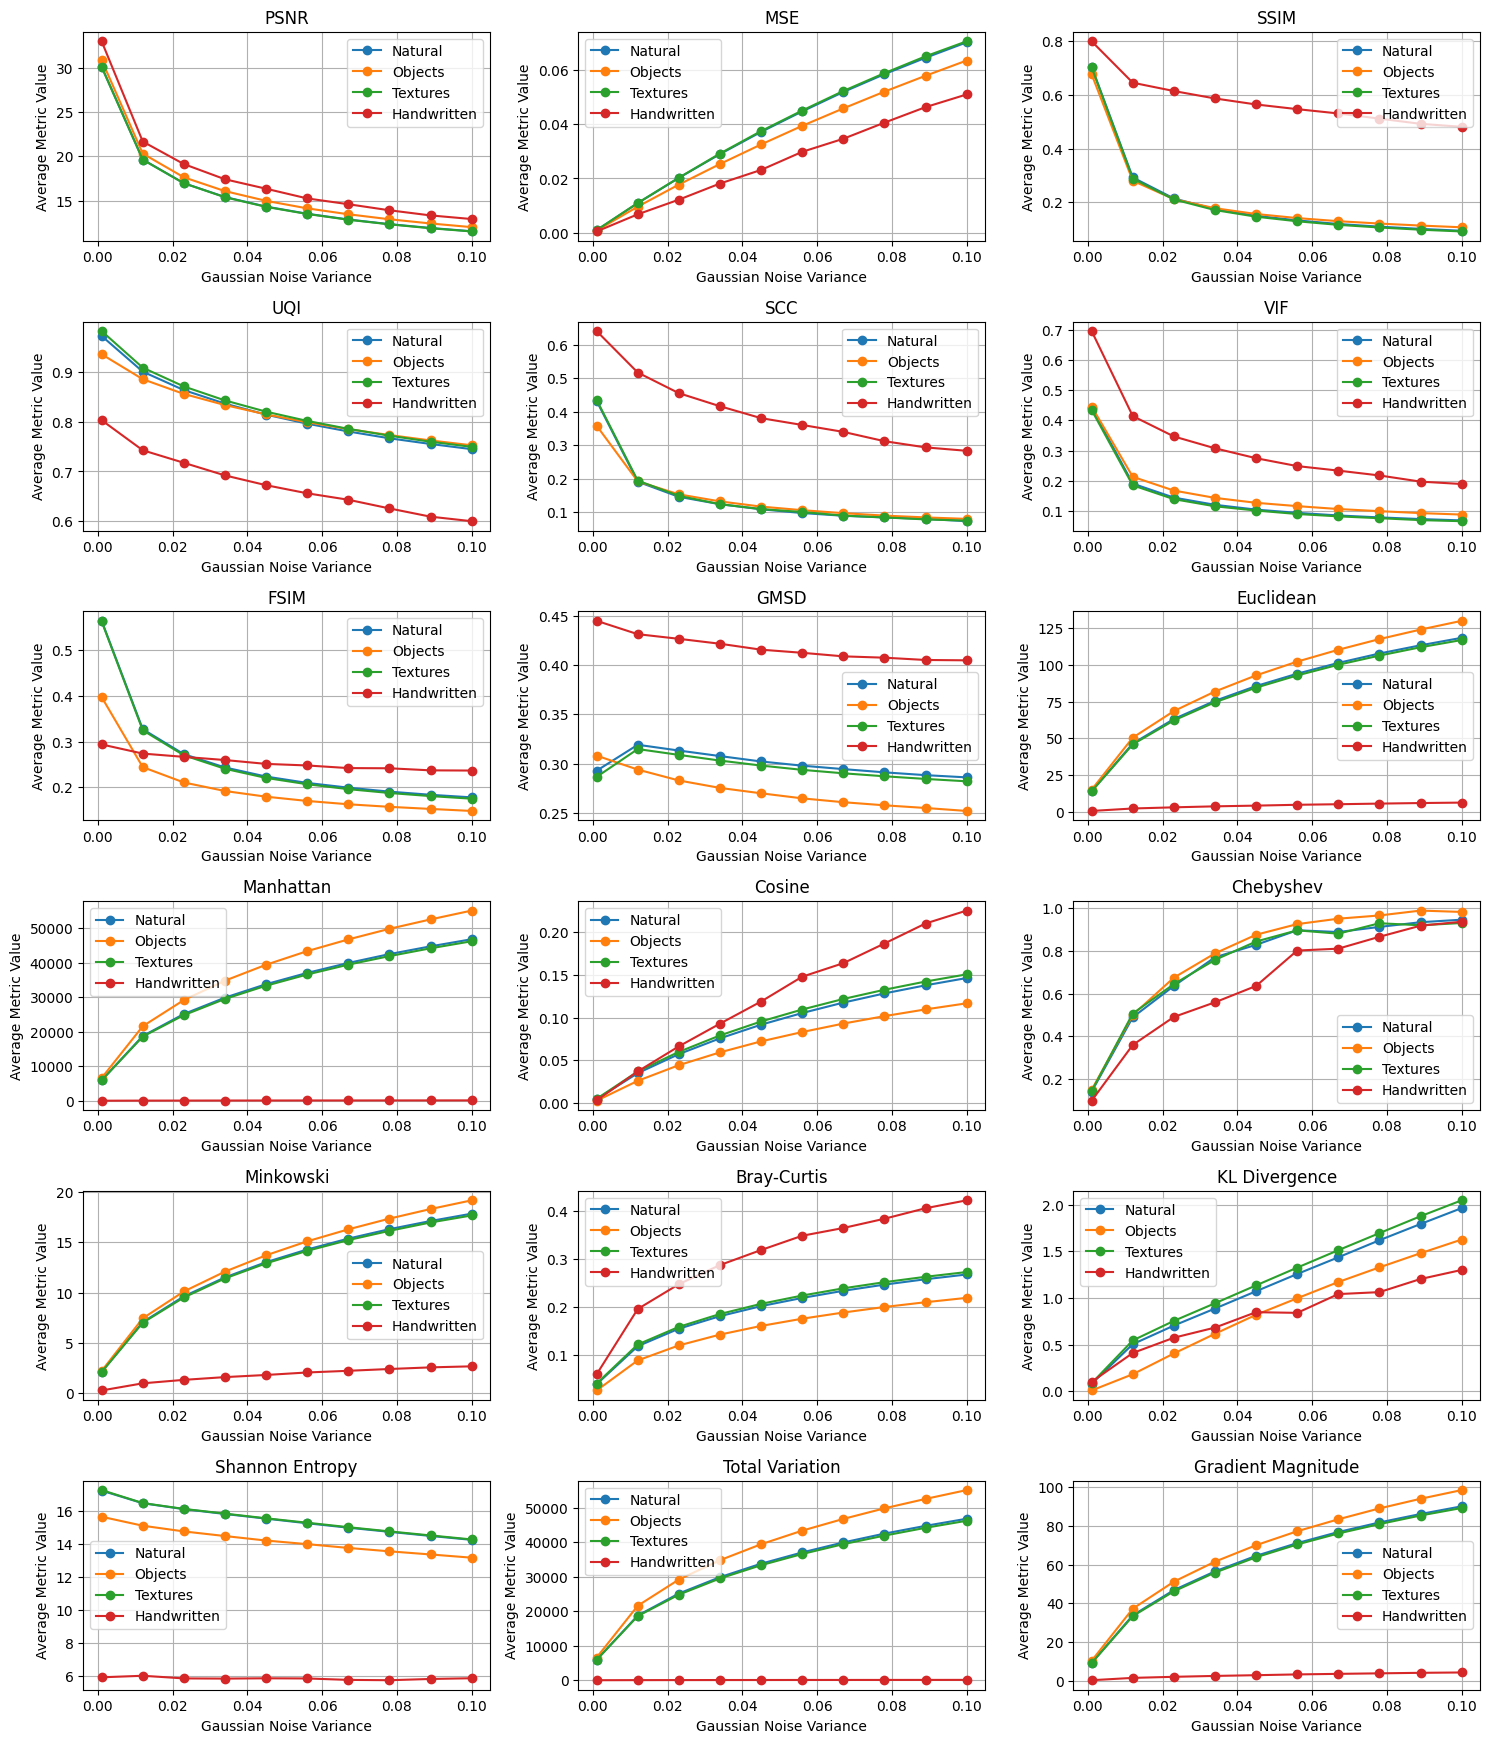

In [ ]:
!pip install sewar
import numpy as np
import matplotlib.pyplot as plt
import sewar
from skimage import data, img_as_float, img_as_ubyte
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
from scipy.spatial.distance import euclidean, cityblock, cosine, chebyshev, minkowski, braycurtis
from scipy.stats import entropy
from skimage.color import rgb2gray, rgba2rgb
from scipy.linalg import norm
from skimage.filters import sobel
from skimage.measure import shannon_entropy
from skimage.util import random_noise
from tensorflow.keras.datasets import mnist
from scipy.ndimage import gaussian_filter

def preprocess_image(image, size=(128, 128)):  # Reduced size for faster computation
    image = img_as_float(image)
    if image.ndim == 3:
        if image.shape[2] == 4:
            image = rgba2rgb(image)
        image = rgb2gray(image)
    return image

def apply_gaussian_noise(image, var):
    noisy_image = random_noise(image, mode='gaussian', var=var)
    return noisy_image

def compute_phase_congruency(image):
    """
    Compute phase congruency using gradient magnitude.
    This is a simplified version for demonstration purposes.
    """
    grad_x = sobel(image, axis=0)
    grad_y = sobel(image, axis=1)
    grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)
    return grad_magnitude

def compute_fsim(original, modified):
    """
    Compute Feature Similarity Index (FSIM) between two images.
    """
    # Compute phase congruency
    pc_original = compute_phase_congruency(original)
    pc_modified = compute_phase_congruency(modified)

    # Compute gradient magnitude
    grad_original = sobel(original)
    grad_modified = sobel(modified)

    # Compute similarity maps
    pc_similarity = (2 * pc_original * pc_modified + 1e-10) / (pc_original**2 + pc_modified**2 + 1e-10)
    grad_similarity = (2 * grad_original * grad_modified + 1e-10) / (grad_original**2 + grad_modified**2 + 1e-10)

    # Combine similarity maps
    similarity_map = pc_similarity * grad_similarity

    # Compute FSIM as the mean of the similarity map
    fsim = np.mean(similarity_map)
    return float(fsim)

def compute_gmsd(original, modified):
    """
    Compute Gradient Magnitude Similarity Deviation (GMSD).
    """
    original_grad = sobel(original)
    modified_grad = sobel(modified)
    gms = (2 * original_grad * modified_grad + 1e-10) / (original_grad**2 + modified_grad**2 + 1e-10)
    gmsd = np.std(gms)
    return float(gmsd)

def compute_metrics(original, modified):
    metrics = {}
    min_side = min(original.shape)
    win_size = min(7, min_side)
    if win_size % 2 == 0:
        win_size -= 1

    original_uint8 = img_as_ubyte(original)
    modified_uint8 = img_as_ubyte(modified)

    ##################################################
    metrics['SSIM'] = float(ssim(original, modified, data_range=1, win_size=win_size))
    # metrics['MS-SSIM'] = float(sewar.msssim(original_uint8, modified_uint8))  # Commented out for speed
    metrics['UQI'] = float(sewar.uqi(original_uint8, modified_uint8))
    metrics['SCC'] = float(sewar.scc(original_uint8, modified_uint8))
    metrics['VIF'] = float(sewar.vifp(original_uint8, modified_uint8))
    metrics['FSIM'] = compute_fsim(original, modified)  # Added custom FSIM
    metrics['GMSD'] = compute_gmsd(original, modified)  # Added GMSD (custom implementation)

    ###############################################
    metrics['PSNR'] = float(psnr(original, modified, data_range=1))
    metrics['MSE'] = float(np.mean((original - modified) ** 2))
    metrics['Euclidean'] = float(euclidean(original.ravel(), modified.ravel()))
    metrics['Manhattan'] = float(cityblock(original.ravel(), modified.ravel()))
    metrics['Cosine'] = float(cosine(original.ravel(), modified.ravel()))
    metrics['Chebyshev'] = float(chebyshev(original.ravel(), modified.ravel()))
    metrics['Minkowski'] = float(minkowski(original.ravel(), modified.ravel(), p=3))
    metrics['Bray-Curtis'] = float(braycurtis(original.ravel(), modified.ravel()))
    metrics['KL Divergence'] = float(entropy(original.ravel() + 1e-10, modified.ravel() + 1e-10))
    metrics['Shannon Entropy'] = float(shannon_entropy(modified))
    metrics['Total Variation'] = float(np.sum(np.abs(original - modified)))
    metrics['Gradient Magnitude'] = float(norm(sobel(original) - sobel(modified)))
    return metrics

# Load and preprocess images
categories = {
    "Natural": [preprocess_image(data.astronaut()), preprocess_image(data.camera()),
                 preprocess_image(data.coffee()), preprocess_image(data.chelsea()),
                 preprocess_image(data.clock()), preprocess_image(data.page()),
                 preprocess_image(data.coins()), preprocess_image(data.brick()),
                 preprocess_image(data.text()), preprocess_image(data.hubble_deep_field())],
    "Objects": [preprocess_image(data.checkerboard()), preprocess_image(data.grass()),
                 preprocess_image(data.moon()), preprocess_image(data.rocket()),
                 preprocess_image(data.horse()), preprocess_image(data.camera()),
                 preprocess_image(data.lily()), preprocess_image(data.cell()),
                 preprocess_image(data.camera())],
    "Textures": [preprocess_image(data.brick()), preprocess_image(data.text()),
                  preprocess_image(data.camera()), preprocess_image(data.page()),
                  preprocess_image(data.coins()), preprocess_image(data.chelsea()),
                  preprocess_image(data.clock()), preprocess_image(data.coffee()),
                  preprocess_image(data.hubble_deep_field())],
    "Handwritten": [preprocess_image(mnist.load_data()[0][0][i] / 255.0) for i in range(10)]
}

# Define noise levels and initialize results
noise_levels = np.linspace(0.001, 0.1, 10)  # Variance levels for Gaussian noise
metric_names = list(compute_metrics(np.zeros((10, 10), dtype=np.float32), np.zeros((10, 10), dtype=np.float32)).keys())

results = {category: {key: np.zeros(len(noise_levels)) for key in metric_names} for category in categories}

# Compute metrics for different noise levels
for category, images in categories.items():
    for image in images:
        for i, var in enumerate(noise_levels):
            noisy_image = apply_gaussian_noise(image, var)
            metrics = compute_metrics(image, noisy_image)
            for key in results[category]:
                results[category][key][i] += metrics[key]

# Normalize results
for category in results:
    for key in results[category]:
        results[category][key] /= len(categories[category])

# Plot the results
fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))
axes = axes.ravel()

for i, key in enumerate(results['Natural']):
    for category in results:
        axes[i].plot(noise_levels, results[category][key], marker='o', label=category)
    axes[i].set_title(key)
    axes[i].set_xlabel("Gaussian Noise Variance")
    axes[i].set_ylabel("Average Metric Value")
    axes[i].legend()
    axes[i].grid()

# Clean up empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/Image Results/image_noise_quality_metrics.png")
plt.show()

In [ ]:
import time
import pandas as pd

# Modify compute_metrics function to measure time complexity
def compute_metrics_with_timing(original, modified):
    metrics = {}
    times = {}

    min_side = min(original.shape)
    win_size = min(7, min_side)
    if win_size % 2 == 0:
        win_size -= 1

    original_uint8 = img_as_ubyte(original)
    modified_uint8 = img_as_ubyte(modified)

    for metric_name, metric_func in [
        ('PSNR', lambda: psnr(original, modified, data_range=1)),
        ('MSE', lambda: np.mean((original - modified) ** 2)),
        ('SSIM', lambda: ssim(original, modified, data_range=1, win_size=win_size)),
        ('UQI', lambda: sewar.uqi(original_uint8, modified_uint8)),
        ('SCC', lambda: sewar.scc(original_uint8, modified_uint8)),
        ('VIF', lambda: sewar.vifp(original_uint8, modified_uint8)),
        ('FSIM', lambda: compute_fsim(original, modified)),
        ('GMSD', lambda: compute_gmsd(original, modified)),
        ('Euclidean', lambda: euclidean(original.ravel(), modified.ravel())),
        ('Manhattan', lambda: cityblock(original.ravel(), modified.ravel())),
        ('Cosine', lambda: cosine(original.ravel(), modified.ravel())),
        ('Chebyshev', lambda: chebyshev(original.ravel(), modified.ravel())),
        ('Minkowski', lambda: minkowski(original.ravel(), modified.ravel(), p=3)),
        ('Bray-Curtis', lambda: braycurtis(original.ravel(), modified.ravel())),
        ('KL Divergence', lambda: entropy(original.ravel() + 1e-10, modified.ravel() + 1e-10)),
        ('Shannon Entropy', lambda: shannon_entropy(modified)),
        ('Total Variation', lambda: np.sum(np.abs(original - modified))),
        ('Gradient Magnitude', lambda: norm(sobel(original) - sobel(modified)))
    ]:
        start_time = time.time()
        metrics[metric_name] = float(metric_func())
        times[metric_name] = time.time() - start_time

    return metrics, times

# Initialize results storage
time_results = {category: {key: np.zeros(len(noise_levels)) for key in metric_names} for category in categories}

# Compute metrics and timing
for category, images in categories.items():
    for image in images:
        for i, var in enumerate(noise_levels):
            noisy_image = apply_gaussian_noise(image, var)
            metrics, times = compute_metrics_with_timing(image, noisy_image)
            for key in results[category]:
                results[category][key][i] += metrics[key]
                time_results[category][key][i] += times[key]

# Normalize results
for category in results:
    for key in results[category]:
        results[category][key] /= len(categories[category])
        time_results[category][key] /= len(categories[category])

# Export results to Excel
with pd.ExcelWriter("image_quality_metrics.xlsx") as writer:
    for category in results:
        df_metrics = pd.DataFrame(results[category], index=noise_levels)
        df_metrics.index.name = "Noise Variance"
        df_metrics.to_excel(writer, sheet_name=f"Metrics_{category}")

        df_times = pd.DataFrame(time_results[category], index=noise_levels)
        df_times.index.name = "Noise Variance"
        df_times.to_excel(writer, sheet_name=f"Time_{category}")

print("Results saved to image_quality_metrics.xlsx")


Results saved to image_quality_metrics.xlsx


# Dilation Radius Effect

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)
/usr/local/lib/python3.11/dist-packages/sewar/full_ref.py:349: RuntimeWarning: invalid value encountered in scalar divide
  return num/den
/usr/local/lib/python3.11/dist-packages/scipy/spatial/distance.py:647: RuntimeWarning: invalid value encountered in divide
  dist = 1.0 - uv / math.sqrt(uu * vv)
/usr/local/lib/python3.11/dist-packages/scipy/spatial/distance.py:1128: RuntimeWarning: invalid value encountered in scalar divide
  return l1_diff.sum() / l1_sum.sum()


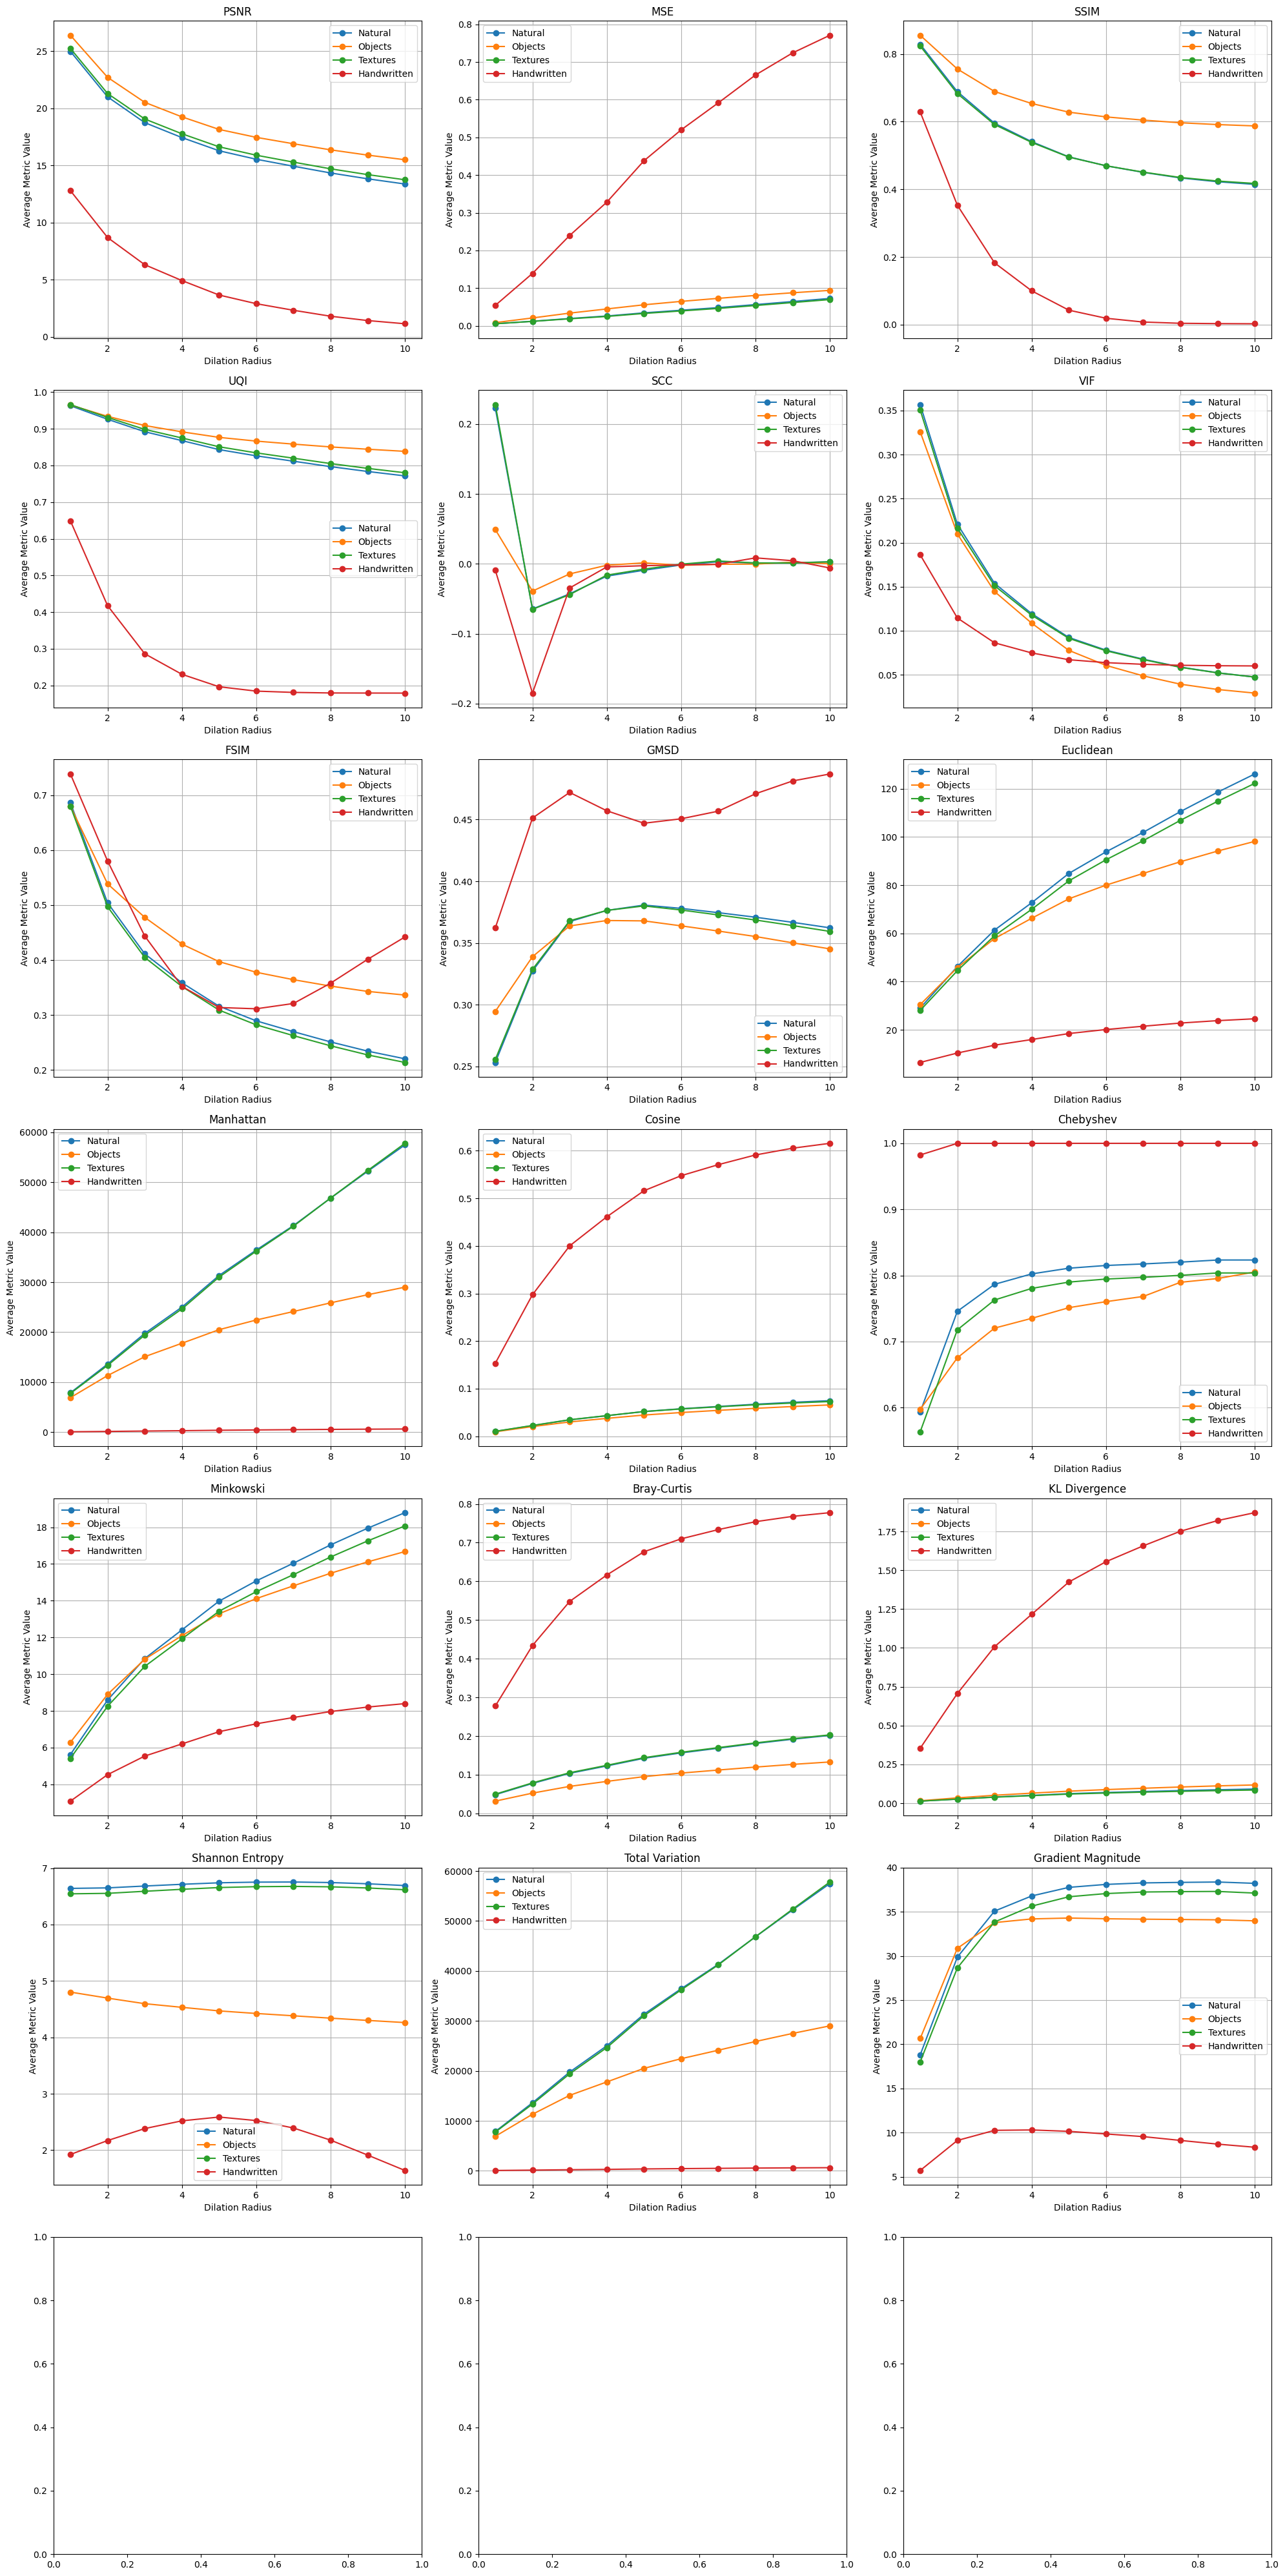

In [ ]:
!pip install sewar
import numpy as np
import matplotlib.pyplot as plt
import sewar
from skimage import data, img_as_float, img_as_ubyte
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
from scipy.spatial.distance import euclidean, cityblock, cosine, chebyshev, minkowski, braycurtis
from scipy.stats import entropy
from skimage.color import rgb2gray, rgba2rgb
from scipy.linalg import norm
from skimage.filters import sobel
from skimage.measure import shannon_entropy
from skimage.morphology import dilation, disk
from tensorflow.keras.datasets import mnist
from scipy.ndimage import gaussian_filter

def preprocess_image(image, size=(128, 128)):  # Reduced size for faster computation
    image = img_as_float(image)
    if image.ndim == 3:
        if image.shape[2] == 4:
            image = rgba2rgb(image)
        image = rgb2gray(image)
    return image

def apply_dilation(image, radius):
    """
    Apply dilation to the image using a disk-shaped structuring element.
    """
    image_uint8 = img_as_ubyte(image)  # Convert to uint8 for morphological operations
    selem = disk(radius)
    dilated_image = dilation(image_uint8, selem)
    return img_as_float(dilated_image)  # Convert back to float for metric calculations

def compute_phase_congruency(image):
    """
    Compute phase congruency using gradient magnitude.
    This is a simplified version for demonstration purposes.
    """
    grad_x = sobel(image, axis=0)
    grad_y = sobel(image, axis=1)
    grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)
    return grad_magnitude

def compute_fsim(original, modified):
    """
    Compute Feature Similarity Index (FSIM) between two images.
    """
    # Compute phase congruency
    pc_original = compute_phase_congruency(original)
    pc_modified = compute_phase_congruency(modified)

    # Compute gradient magnitude
    grad_original = sobel(original)
    grad_modified = sobel(modified)

    # Compute similarity maps
    pc_similarity = (2 * pc_original * pc_modified + 1e-10) / (pc_original**2 + pc_modified**2 + 1e-10)
    grad_similarity = (2 * grad_original * grad_modified + 1e-10) / (grad_original**2 + grad_modified**2 + 1e-10)

    # Combine similarity maps
    similarity_map = pc_similarity * grad_similarity

    # Compute FSIM as the mean of the similarity map
    fsim = np.mean(similarity_map)
    return float(fsim)

def compute_gmsd(original, modified):
    """
    Compute Gradient Magnitude Similarity Deviation (GMSD).
    """
    original_grad = sobel(original)
    modified_grad = sobel(modified)
    gms = (2 * original_grad * modified_grad + 1e-10) / (original_grad**2 + modified_grad**2 + 1e-10)
    gmsd = np.std(gms)
    return float(gmsd)

def compute_metrics(original, modified):
    metrics = {}
    min_side = min(original.shape)
    win_size = min(7, min_side)
    if win_size % 2 == 0:
        win_size -= 1

    original_uint8 = img_as_ubyte(original)
    modified_uint8 = img_as_ubyte(modified)

    metrics['PSNR'] = float(psnr(original, modified, data_range=1))
    metrics['MSE'] = float(np.mean((original - modified) ** 2))
    metrics['SSIM'] = float(ssim(original, modified, data_range=1, win_size=win_size))
    # metrics['MS-SSIM'] = float(sewar.msssim(original_uint8, modified_uint8))  # Commented out for speed
    metrics['UQI'] = float(sewar.uqi(original_uint8, modified_uint8))
    metrics['SCC'] = float(sewar.scc(original_uint8, modified_uint8))
    metrics['VIF'] = float(sewar.vifp(original_uint8, modified_uint8))
    metrics['FSIM'] = compute_fsim(original, modified)  # Added custom FSIM
    metrics['GMSD'] = compute_gmsd(original, modified)  # Added GMSD (custom implementation)
    metrics['Euclidean'] = float(euclidean(original.ravel(), modified.ravel()))
    metrics['Manhattan'] = float(cityblock(original.ravel(), modified.ravel()))
    metrics['Cosine'] = float(cosine(original.ravel(), modified.ravel()))
    metrics['Chebyshev'] = float(chebyshev(original.ravel(), modified.ravel()))
    metrics['Minkowski'] = float(minkowski(original.ravel(), modified.ravel(), p=3))
    metrics['Bray-Curtis'] = float(braycurtis(original.ravel(), modified.ravel()))
    metrics['KL Divergence'] = float(entropy(original.ravel() + 1e-10, modified.ravel() + 1e-10))
    metrics['Shannon Entropy'] = float(shannon_entropy(modified))
    metrics['Total Variation'] = float(np.sum(np.abs(original - modified)))
    metrics['Gradient Magnitude'] = float(norm(sobel(original) - sobel(modified)))
    return metrics

# Load and preprocess images
categories = {
    "Natural": [preprocess_image(data.astronaut()), preprocess_image(data.camera()),
                 preprocess_image(data.coffee()), preprocess_image(data.chelsea()),
                 preprocess_image(data.clock()), preprocess_image(data.page()),
                 preprocess_image(data.coins()), preprocess_image(data.brick()),
                 preprocess_image(data.text()), preprocess_image(data.hubble_deep_field())],
    "Objects": [preprocess_image(data.checkerboard()), preprocess_image(data.grass()),
                 preprocess_image(data.moon()), preprocess_image(data.rocket()),
                 preprocess_image(data.horse()), preprocess_image(data.camera()),
                 preprocess_image(data.lily()), preprocess_image(data.cell()),
                 preprocess_image(data.camera())],
    "Textures": [preprocess_image(data.brick()), preprocess_image(data.text()),
                  preprocess_image(data.camera()), preprocess_image(data.page()),
                  preprocess_image(data.coins()), preprocess_image(data.chelsea()),
                  preprocess_image(data.clock()), preprocess_image(data.coffee()),
                  preprocess_image(data.hubble_deep_field())],
    "Handwritten": [preprocess_image(mnist.load_data()[0][0][i] / 255.0) for i in range(10)]
}

# Define dilation levels and initialize results
dilation_levels = np.arange(1, 11)  # Dilation radii from 1 to 10
metric_names = list(compute_metrics(np.zeros((10, 10), dtype=np.float32), np.zeros((10, 10), dtype=np.float32)).keys())

results = {category: {key: np.zeros(len(dilation_levels)) for key in metric_names} for category in categories}

# Compute metrics for different dilation levels
for category, images in categories.items():
    for image in images:
        for i, radius in enumerate(dilation_levels):
            dilated_image = apply_dilation(image, radius)
            metrics = compute_metrics(image, dilated_image)
            for key in results[category]:
                results[category][key][i] += metrics[key]

# Normalize results
for category in results:
    for key in results[category]:
        results[category][key] /= len(categories[category])

# Plot the results
fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))
axes = axes.ravel()

for i, key in enumerate(results['Natural']):
    for category in results:
        axes[i].plot(dilation_levels, results[category][key], marker='o', label=category)
    axes[i].set_title(key)
    axes[i].set_xlabel("Dilation Radius")
    axes[i].set_ylabel("Average Metric Value")
    axes[i].legend()
    axes[i].grid()

# Clean up empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("/content/drive/My Drive/Colab Notebooks/Image_Results/image_dilation_quality_metrics.png")
plt.show()

# Contrast Effect

/usr/local/lib/python3.11/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)
/usr/local/lib/python3.11/dist-packages/sewar/full_ref.py:349: RuntimeWarning: invalid value encountered in scalar divide
  return num/den
/usr/local/lib/python3.11/dist-packages/scipy/spatial/distance.py:647: RuntimeWarning: invalid value encountered in divide
  dist = 1.0 - uv / math.sqrt(uu * vv)
/usr/local/lib/python3.11/dist-packages/scipy/spatial/distance.py:1128: RuntimeWarning: invalid value encountered in scalar divide
  return l1_diff.sum() / l1_sum.sum()


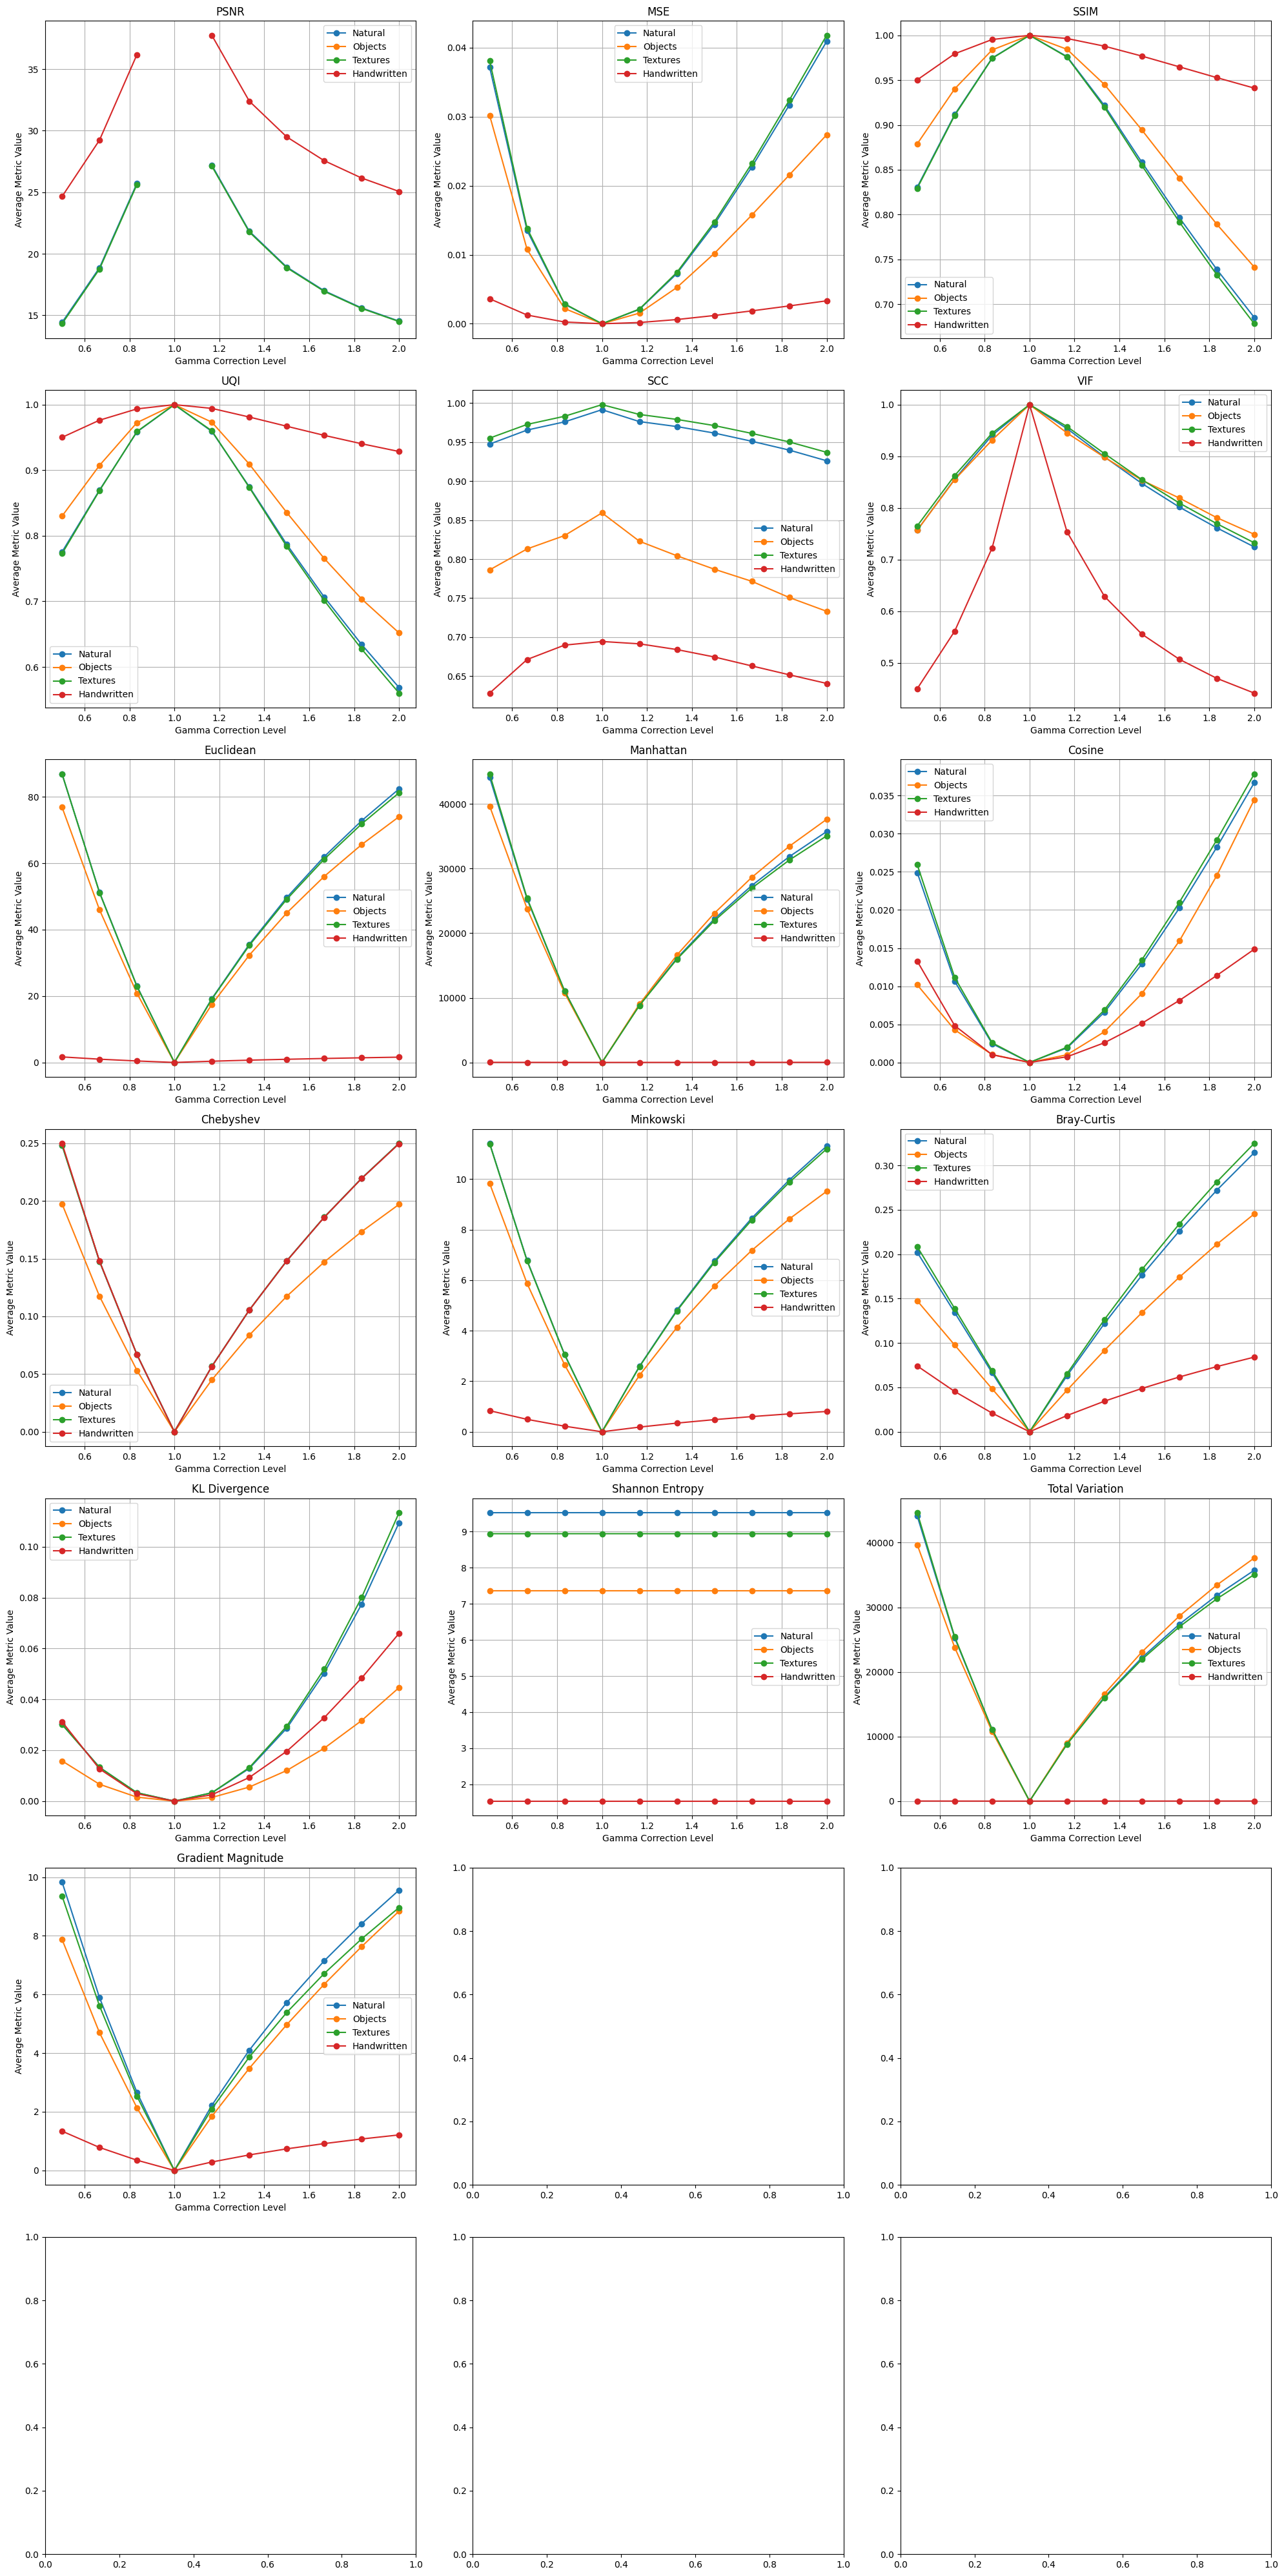

In [ ]:
!pip install sewar
import numpy as np
import matplotlib.pyplot as plt
import sewar
from skimage import data, img_as_float, img_as_ubyte, exposure
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
from scipy.spatial.distance import euclidean, cityblock, cosine, chebyshev, minkowski, braycurtis
from scipy.stats import entropy
from skimage.color import rgb2gray, rgba2rgb
from scipy.linalg import norm
from skimage.filters import sobel
from skimage.measure import shannon_entropy
from tensorflow.keras.datasets import mnist

def preprocess_image(image):
    image = img_as_float(image)
    if image.ndim == 3:
        if image.shape[2] == 4:
            image = rgba2rgb(image)
        image = rgb2gray(image)
    return image

def apply_contrast_adjustment(image, gamma):
    """
    Apply contrast adjustment using gamma correction.
    """
    adjusted_image = exposure.adjust_gamma(image, gamma)
    return adjusted_image

def compute_metrics(original, modified):
    metrics = {}
    min_side = min(original.shape)
    win_size = min(7, min_side)
    if win_size % 2 == 0:
        win_size -= 1

    original_uint8 = img_as_ubyte(original)
    modified_uint8 = img_as_ubyte(modified)

    metrics['PSNR'] = float(psnr(original, modified, data_range=1))
    metrics['MSE'] = float(np.mean((original - modified) ** 2))
    metrics['SSIM'] = float(ssim(original, modified, data_range=1, win_size=win_size))
    metrics['UQI'] = float(sewar.uqi(original_uint8, modified_uint8))
    metrics['SCC'] = float(sewar.scc(original_uint8, modified_uint8))
    metrics['VIF'] = float(sewar.vifp(original_uint8, modified_uint8))
    metrics['Euclidean'] = float(euclidean(original.ravel(), modified.ravel()))
    metrics['Manhattan'] = float(cityblock(original.ravel(), modified.ravel()))
    metrics['Cosine'] = float(cosine(original.ravel(), modified.ravel()))
    metrics['Chebyshev'] = float(chebyshev(original.ravel(), modified.ravel()))
    metrics['Minkowski'] = float(minkowski(original.ravel(), modified.ravel(), p=3))
    metrics['Bray-Curtis'] = float(braycurtis(original.ravel(), modified.ravel()))
    metrics['KL Divergence'] = float(entropy(original.ravel() + 1e-10, modified.ravel() + 1e-10))
    metrics['Shannon Entropy'] = float(shannon_entropy(modified))
    metrics['Total Variation'] = float(np.sum(np.abs(original - modified)))
    metrics['Gradient Magnitude'] = float(norm(sobel(original) - sobel(modified)))
    return metrics

# Load and preprocess images
categories = {
    "Natural": [preprocess_image(data.astronaut()), preprocess_image(data.camera()),
                 preprocess_image(data.coffee()), preprocess_image(data.chelsea()),
                 preprocess_image(data.clock()), preprocess_image(data.page()),
                 preprocess_image(data.coins()), preprocess_image(data.brick()),
                 preprocess_image(data.text()), preprocess_image(data.hubble_deep_field())],
    "Objects": [preprocess_image(data.checkerboard()), preprocess_image(data.grass()),
                 preprocess_image(data.moon()), preprocess_image(data.rocket()),
                 preprocess_image(data.horse()), preprocess_image(data.camera()),
                 preprocess_image(data.lily()), preprocess_image(data.cell()),
                 preprocess_image(data.camera())],
    "Textures": [preprocess_image(data.brick()), preprocess_image(data.text()),
                  preprocess_image(data.camera()), preprocess_image(data.page()),
                  preprocess_image(data.coins()), preprocess_image(data.chelsea()),
                  preprocess_image(data.clock()), preprocess_image(data.coffee()),
                  preprocess_image(data.hubble_deep_field())],
    "Handwritten": [preprocess_image(mnist.load_data()[0][0][i] / 255.0) for i in range(10)]
}

# Define contrast adjustment levels and initialize results
gamma_levels = np.linspace(0.5, 2.0, 10)  # Different contrast levels
metric_names = list(compute_metrics(np.zeros((10, 10), dtype=np.float32), np.zeros((10, 10), dtype=np.float32)).keys())

results = {category: {key: np.zeros(len(gamma_levels)) for key in metric_names} for category in categories}

# Compute metrics for different contrast levels
for category, images in categories.items():
    for image in images:
        for i, gamma in enumerate(gamma_levels):
            adjusted_image = apply_contrast_adjustment(image, gamma)
            metrics = compute_metrics(image, adjusted_image)
            for key in results[category]:
                results[category][key][i] += metrics[key]

# Normalize results
for category in results:
    for key in results[category]:
        results[category][key] /= len(categories[category])

# Plot the results
fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))
axes = axes.ravel()

for i, key in enumerate(results['Natural']):
    for category in results:
        axes[i].plot(gamma_levels, results[category][key], marker='o', label=category)
    axes[i].set_title(key)
    axes[i].set_xlabel("Gamma Correction Level")
    axes[i].set_ylabel("Average Metric Value")
    axes[i].legend()
    axes[i].grid()

# Clean up empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("/content/drive/My Drive/Colab Notebooks/Image_Results/image_contrast_quality_metrics.png")
plt.show()


# Brightness Effect

/usr/local/lib/python3.11/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)
/usr/local/lib/python3.11/dist-packages/sewar/full_ref.py:349: RuntimeWarning: invalid value encountered in scalar divide
  return num/den
/usr/local/lib/python3.11/dist-packages/scipy/spatial/distance.py:647: RuntimeWarning: invalid value encountered in divide
  dist = 1.0 - uv / math.sqrt(uu * vv)
/usr/local/lib/python3.11/dist-packages/scipy/spatial/distance.py:1128: RuntimeWarning: invalid value encountered in scalar divide
  return l1_diff.sum() / l1_sum.sum()


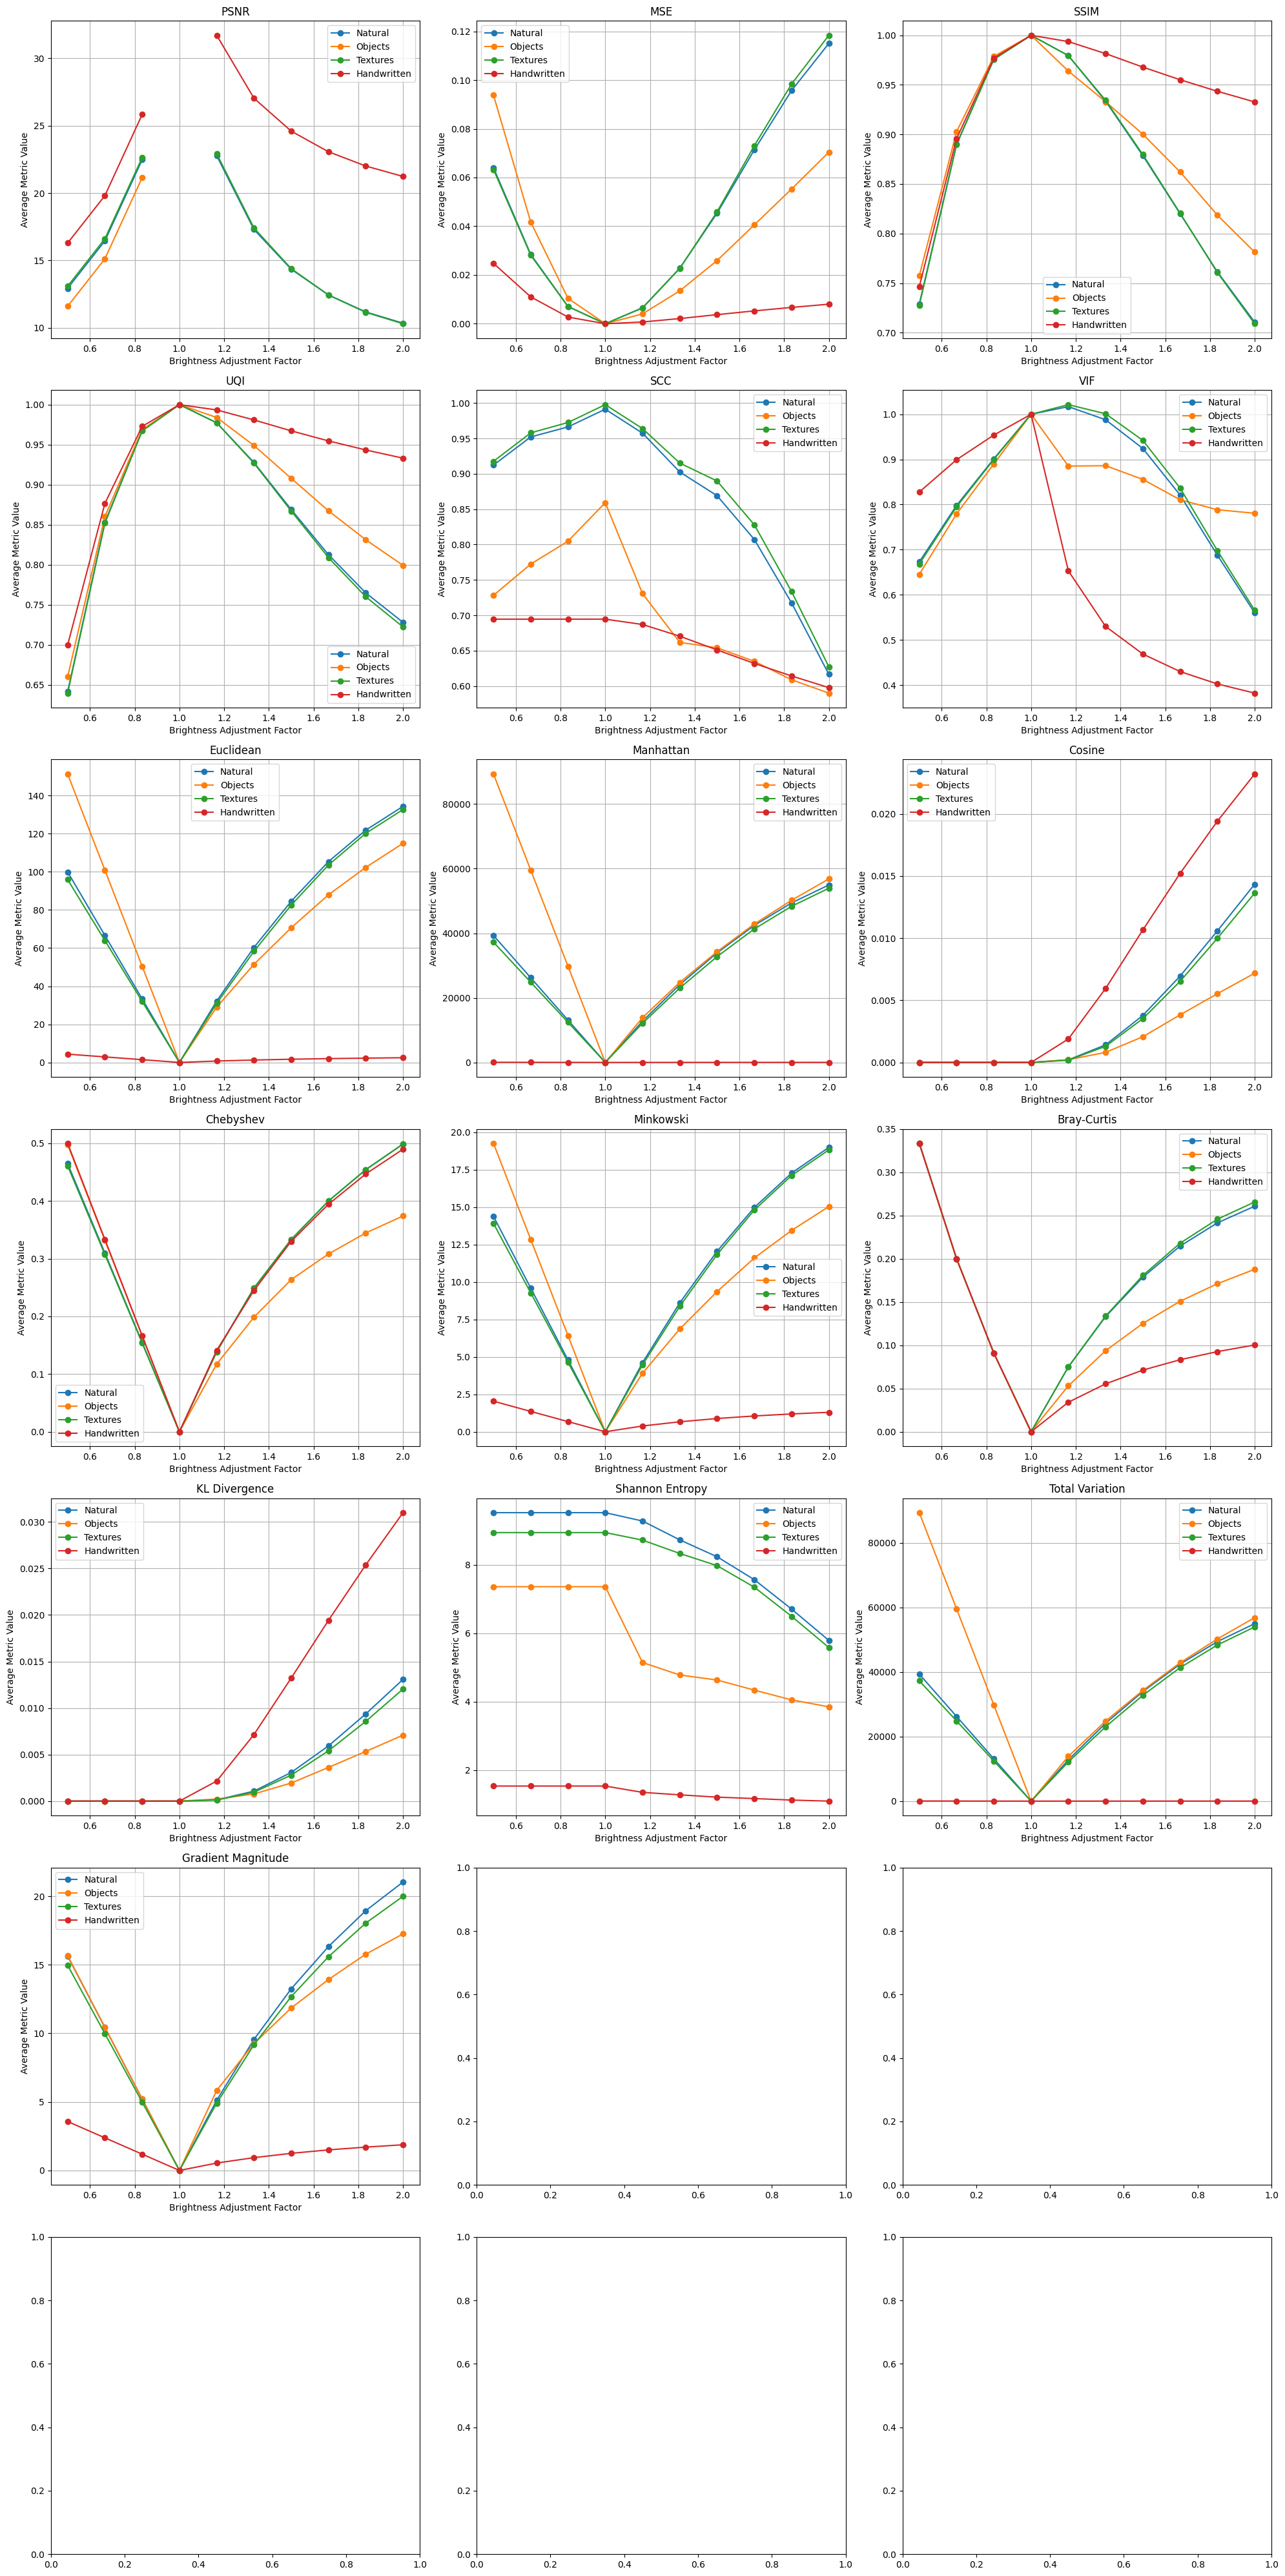

In [ ]:
!pip install sewar
import numpy as np
import matplotlib.pyplot as plt
import sewar
from skimage import data, img_as_float, img_as_ubyte, exposure
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
from scipy.spatial.distance import euclidean, cityblock, cosine, chebyshev, minkowski, braycurtis
from scipy.stats import entropy
from skimage.color import rgb2gray, rgba2rgb
from scipy.linalg import norm
from skimage.filters import sobel
from skimage.measure import shannon_entropy
from tensorflow.keras.datasets import mnist

def preprocess_image(image):
    image = img_as_float(image)
    if image.ndim == 3:
        if image.shape[2] == 4:
            image = rgba2rgb(image)
        image = rgb2gray(image)
    return image

def apply_brightness_adjustment(image, factor):
    """
    Apply brightness adjustment by scaling pixel values.
    """
    adjusted_image = np.clip(image * factor, 0, 1)
    return adjusted_image

def compute_metrics(original, modified):
    metrics = {}
    min_side = min(original.shape)
    win_size = min(7, min_side)
    if win_size % 2 == 0:
        win_size -= 1

    original_uint8 = img_as_ubyte(original)
    modified_uint8 = img_as_ubyte(modified)

    metrics['PSNR'] = float(psnr(original, modified, data_range=1))
    metrics['MSE'] = float(np.mean((original - modified) ** 2))
    metrics['SSIM'] = float(ssim(original, modified, data_range=1, win_size=win_size))
    metrics['UQI'] = float(sewar.uqi(original_uint8, modified_uint8))
    metrics['SCC'] = float(sewar.scc(original_uint8, modified_uint8))
    metrics['VIF'] = float(sewar.vifp(original_uint8, modified_uint8))
    metrics['Euclidean'] = float(euclidean(original.ravel(), modified.ravel()))
    metrics['Manhattan'] = float(cityblock(original.ravel(), modified.ravel()))
    metrics['Cosine'] = float(cosine(original.ravel(), modified.ravel()))
    metrics['Chebyshev'] = float(chebyshev(original.ravel(), modified.ravel()))
    metrics['Minkowski'] = float(minkowski(original.ravel(), modified.ravel(), p=3))
    metrics['Bray-Curtis'] = float(braycurtis(original.ravel(), modified.ravel()))
    metrics['KL Divergence'] = float(entropy(original.ravel() + 1e-10, modified.ravel() + 1e-10))
    metrics['Shannon Entropy'] = float(shannon_entropy(modified))
    metrics['Total Variation'] = float(np.sum(np.abs(original - modified)))
    metrics['Gradient Magnitude'] = float(norm(sobel(original) - sobel(modified)))
    return metrics

# Load and preprocess images
categories = {
    "Natural": [preprocess_image(data.astronaut()), preprocess_image(data.camera()),
                 preprocess_image(data.coffee()), preprocess_image(data.chelsea()),
                 preprocess_image(data.clock()), preprocess_image(data.page()),
                 preprocess_image(data.coins()), preprocess_image(data.brick()),
                 preprocess_image(data.text()), preprocess_image(data.hubble_deep_field())],
    "Objects": [preprocess_image(data.checkerboard()), preprocess_image(data.grass()),
                 preprocess_image(data.moon()), preprocess_image(data.rocket()),
                 preprocess_image(data.horse()), preprocess_image(data.camera()),
                 preprocess_image(data.lily()), preprocess_image(data.cell()),
                 preprocess_image(data.camera())],
    "Textures": [preprocess_image(data.brick()), preprocess_image(data.text()),
                  preprocess_image(data.camera()), preprocess_image(data.page()),
                  preprocess_image(data.coins()), preprocess_image(data.chelsea()),
                  preprocess_image(data.clock()), preprocess_image(data.coffee()),
                  preprocess_image(data.hubble_deep_field())],
    "Handwritten": [preprocess_image(mnist.load_data()[0][0][i] / 255.0) for i in range(10)]
}

# Define brightness adjustment levels and initialize results
brightness_levels = np.linspace(0.5, 2.0, 10)  # Different brightness levels
metric_names = list(compute_metrics(np.zeros((10, 10), dtype=np.float32), np.zeros((10, 10), dtype=np.float32)).keys())

results = {category: {key: np.zeros(len(brightness_levels)) for key in metric_names} for category in categories}

# Compute metrics for different brightness levels
for category, images in categories.items():
    for image in images:
        for i, factor in enumerate(brightness_levels):
            adjusted_image = apply_brightness_adjustment(image, factor)
            metrics = compute_metrics(image, adjusted_image)
            for key in results[category]:
                results[category][key][i] += metrics[key]

# Normalize results
for category in results:
    for key in results[category]:
        results[category][key] /= len(categories[category])

# Plot the results
fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))
axes = axes.ravel()

for i, key in enumerate(results['Natural']):
    for category in results:
        axes[i].plot(brightness_levels, results[category][key], marker='o', label=category)
    axes[i].set_title(key)
    axes[i].set_xlabel("Brightness Adjustment Factor")
    axes[i].set_ylabel("Average Metric Value")
    axes[i].legend()
    axes[i].grid()

# Clean up empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("/content/drive/My Drive/Colab Notebooks/Image_Results/image_brightness_quality_metrics.png")plt.show()


# Illumination Effect

/usr/local/lib/python3.11/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)
/usr/local/lib/python3.11/dist-packages/sewar/full_ref.py:349: RuntimeWarning: invalid value encountered in scalar divide
  return num/den
/usr/local/lib/python3.11/dist-packages/scipy/spatial/distance.py:647: RuntimeWarning: invalid value encountered in divide
  dist = 1.0 - uv / math.sqrt(uu * vv)
/usr/local/lib/python3.11/dist-packages/scipy/spatial/distance.py:1128: RuntimeWarning: invalid value encountered in scalar divide
  return l1_diff.sum() / l1_sum.sum()


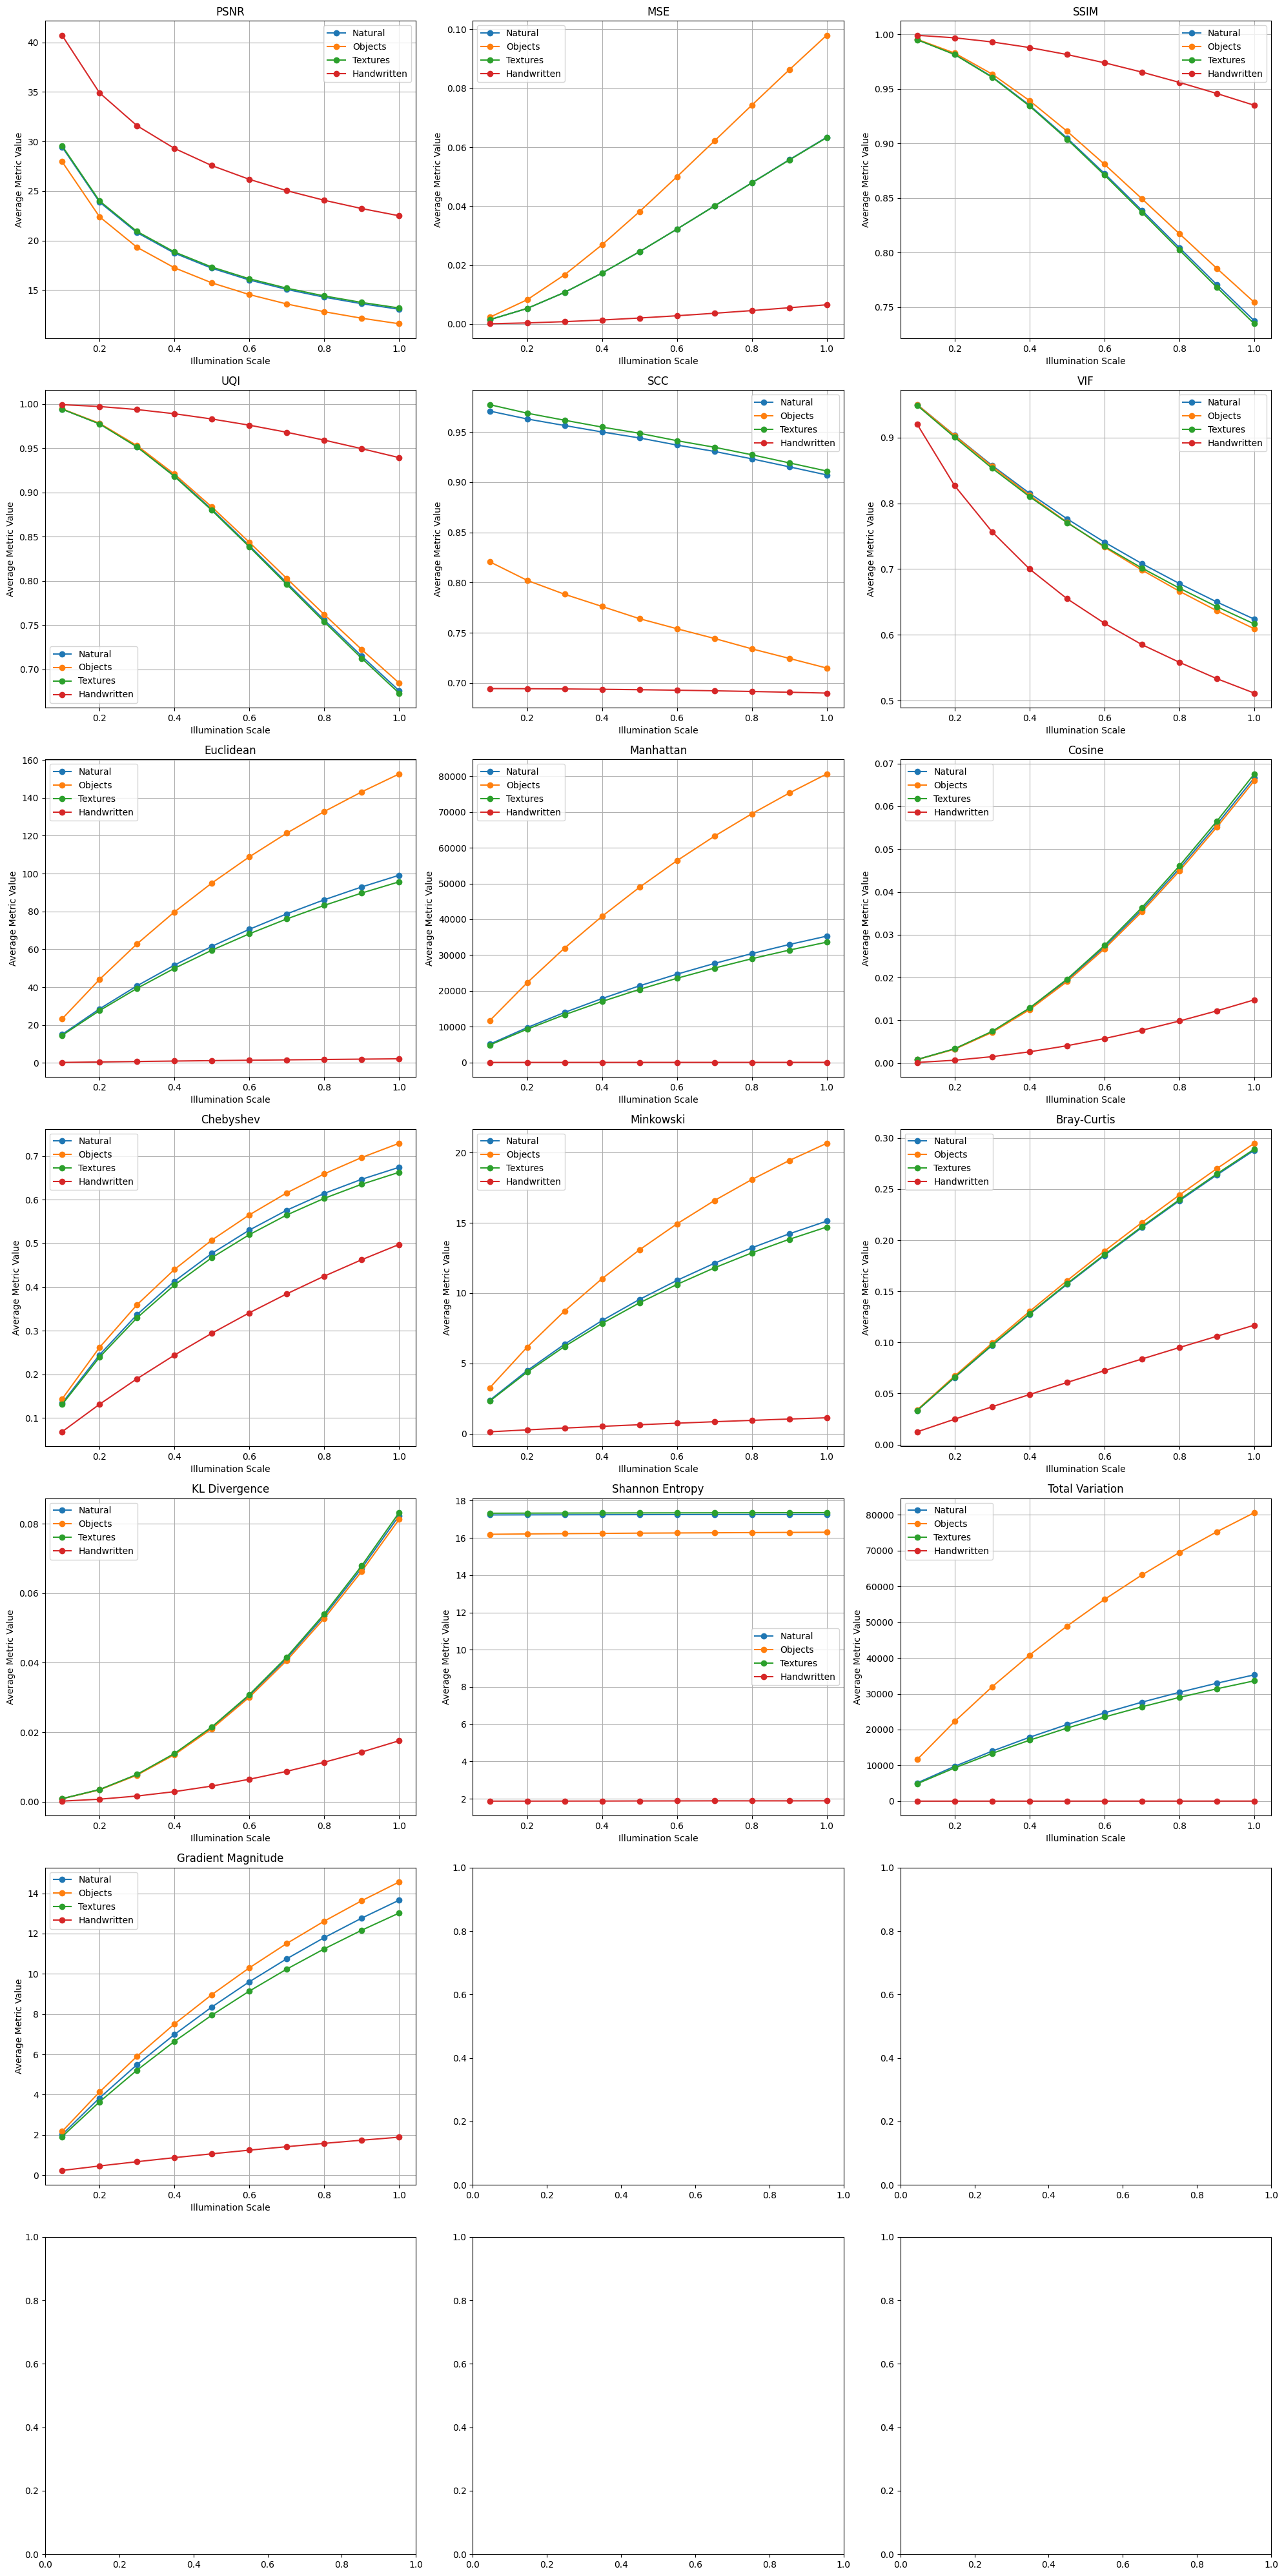

In [ ]:
!pip install sewar
import numpy as np
import matplotlib.pyplot as plt
import sewar
from skimage import data, img_as_float, img_as_ubyte
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
from scipy.spatial.distance import euclidean, cityblock, cosine, chebyshev, minkowski, braycurtis
from scipy.stats import entropy
from skimage.color import rgb2gray, rgba2rgb
from scipy.linalg import norm
from skimage.filters import sobel
from skimage.measure import shannon_entropy
from tensorflow.keras.datasets import mnist

def preprocess_image(image):
    image = img_as_float(image)
    if image.ndim == 3:
        if image.shape[2] == 4:
            image = rgba2rgb(image)
        image = rgb2gray(image)
    return image

def apply_non_uniform_illumination(image, scale=0.5):
    """
    Apply non-uniform illumination effect to the image.
    """
    rows, cols = image.shape
    x, y = np.meshgrid(np.linspace(-1, 1, cols), np.linspace(-1, 1, rows))
    illumination_mask = np.exp(-scale * (x**2 + y**2))
    modified_image = image * illumination_mask
    return np.clip(modified_image, 0, 1)

def compute_metrics(original, modified):
    metrics = {}
    min_side = min(original.shape)
    win_size = min(7, min_side)
    if win_size % 2 == 0:
        win_size -= 1

    original_uint8 = img_as_ubyte(original)
    modified_uint8 = img_as_ubyte(modified)

    metrics['PSNR'] = float(psnr(original, modified, data_range=1))
    metrics['MSE'] = float(np.mean((original - modified) ** 2))
    metrics['SSIM'] = float(ssim(original, modified, data_range=1, win_size=win_size))
    metrics['UQI'] = float(sewar.uqi(original_uint8, modified_uint8))
    metrics['SCC'] = float(sewar.scc(original_uint8, modified_uint8))
    metrics['VIF'] = float(sewar.vifp(original_uint8, modified_uint8))
    metrics['Euclidean'] = float(euclidean(original.ravel(), modified.ravel()))
    metrics['Manhattan'] = float(cityblock(original.ravel(), modified.ravel()))
    metrics['Cosine'] = float(cosine(original.ravel(), modified.ravel()))
    metrics['Chebyshev'] = float(chebyshev(original.ravel(), modified.ravel()))
    metrics['Minkowski'] = float(minkowski(original.ravel(), modified.ravel(), p=3))
    metrics['Bray-Curtis'] = float(braycurtis(original.ravel(), modified.ravel()))
    metrics['KL Divergence'] = float(entropy(original.ravel() + 1e-10, modified.ravel() + 1e-10))
    metrics['Shannon Entropy'] = float(shannon_entropy(modified))
    metrics['Total Variation'] = float(np.sum(np.abs(original - modified)))
    metrics['Gradient Magnitude'] = float(norm(sobel(original) - sobel(modified)))
    return metrics

# Load and preprocess images
categories = {
    "Natural": [preprocess_image(data.astronaut()), preprocess_image(data.camera()),
                 preprocess_image(data.coffee()), preprocess_image(data.chelsea()),
                 preprocess_image(data.clock()), preprocess_image(data.page()),
                 preprocess_image(data.coins()), preprocess_image(data.brick()),
                 preprocess_image(data.text()), preprocess_image(data.hubble_deep_field())],
    "Objects": [preprocess_image(data.checkerboard()), preprocess_image(data.grass()),
                 preprocess_image(data.moon()), preprocess_image(data.rocket()),
                 preprocess_image(data.horse()), preprocess_image(data.camera()),
                 preprocess_image(data.lily()), preprocess_image(data.cell()),
                 preprocess_image(data.camera())],
    "Textures": [preprocess_image(data.brick()), preprocess_image(data.text()),
                  preprocess_image(data.camera()), preprocess_image(data.page()),
                  preprocess_image(data.coins()), preprocess_image(data.chelsea()),
                  preprocess_image(data.clock()), preprocess_image(data.coffee()),
                  preprocess_image(data.hubble_deep_field())],
    "Handwritten": [preprocess_image(mnist.load_data()[0][0][i] / 255.0) for i in range(10)]
}

# Define illumination levels and initialize results
illumination_scales = np.linspace(0.1, 1.0, 10)  # Different illumination scales
metric_names = list(compute_metrics(np.zeros((10, 10), dtype=np.float32), np.zeros((10, 10), dtype=np.float32)).keys())

results = {category: {key: np.zeros(len(illumination_scales)) for key in metric_names} for category in categories}

# Compute metrics for different illumination levels
for category, images in categories.items():
    for image in images:
        for i, scale in enumerate(illumination_scales):
            illuminated_image = apply_non_uniform_illumination(image, scale)
            metrics = compute_metrics(image, illuminated_image)
            for key in results[category]:
                results[category][key][i] += metrics[key]

# Normalize results
for category in results:
    for key in results[category]:
        results[category][key] /= len(categories[category])

# Plot the results
fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))
axes = axes.ravel()

for i, key in enumerate(results['Natural']):
    for category in results:
        axes[i].plot(illumination_scales, results[category][key], marker='o', label=category)
    axes[i].set_title(key)
    axes[i].set_xlabel("Illumination Scale")
    axes[i].set_ylabel("Average Metric Value")
    axes[i].legend()
    axes[i].grid()

# Clean up empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("/content/drive/My Drive/Colab Notebooks/Image_Results/image_illumination_quality_metrics.png")
plt.show()


# Fog Effect

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.11/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)
/usr/local/lib/python3.11/dist-packages/sewar/full_ref.py:349: RuntimeWarning: invalid value encountered in scalar divide
  return num/den
/usr/local/lib/python3.11/dist-packages/scipy/spatial/distance.py:647: RuntimeWarning: invalid value encountered in divide
  dist = 1.0 - uv / math.sqrt(uu * vv)
/usr/local/lib/python3.11/dist-packages/scipy/spatial/distance.py:1128: RuntimeWarning: invalid value encountered in scalar divide
  return l1_diff.sum() / l1_sum.sum()


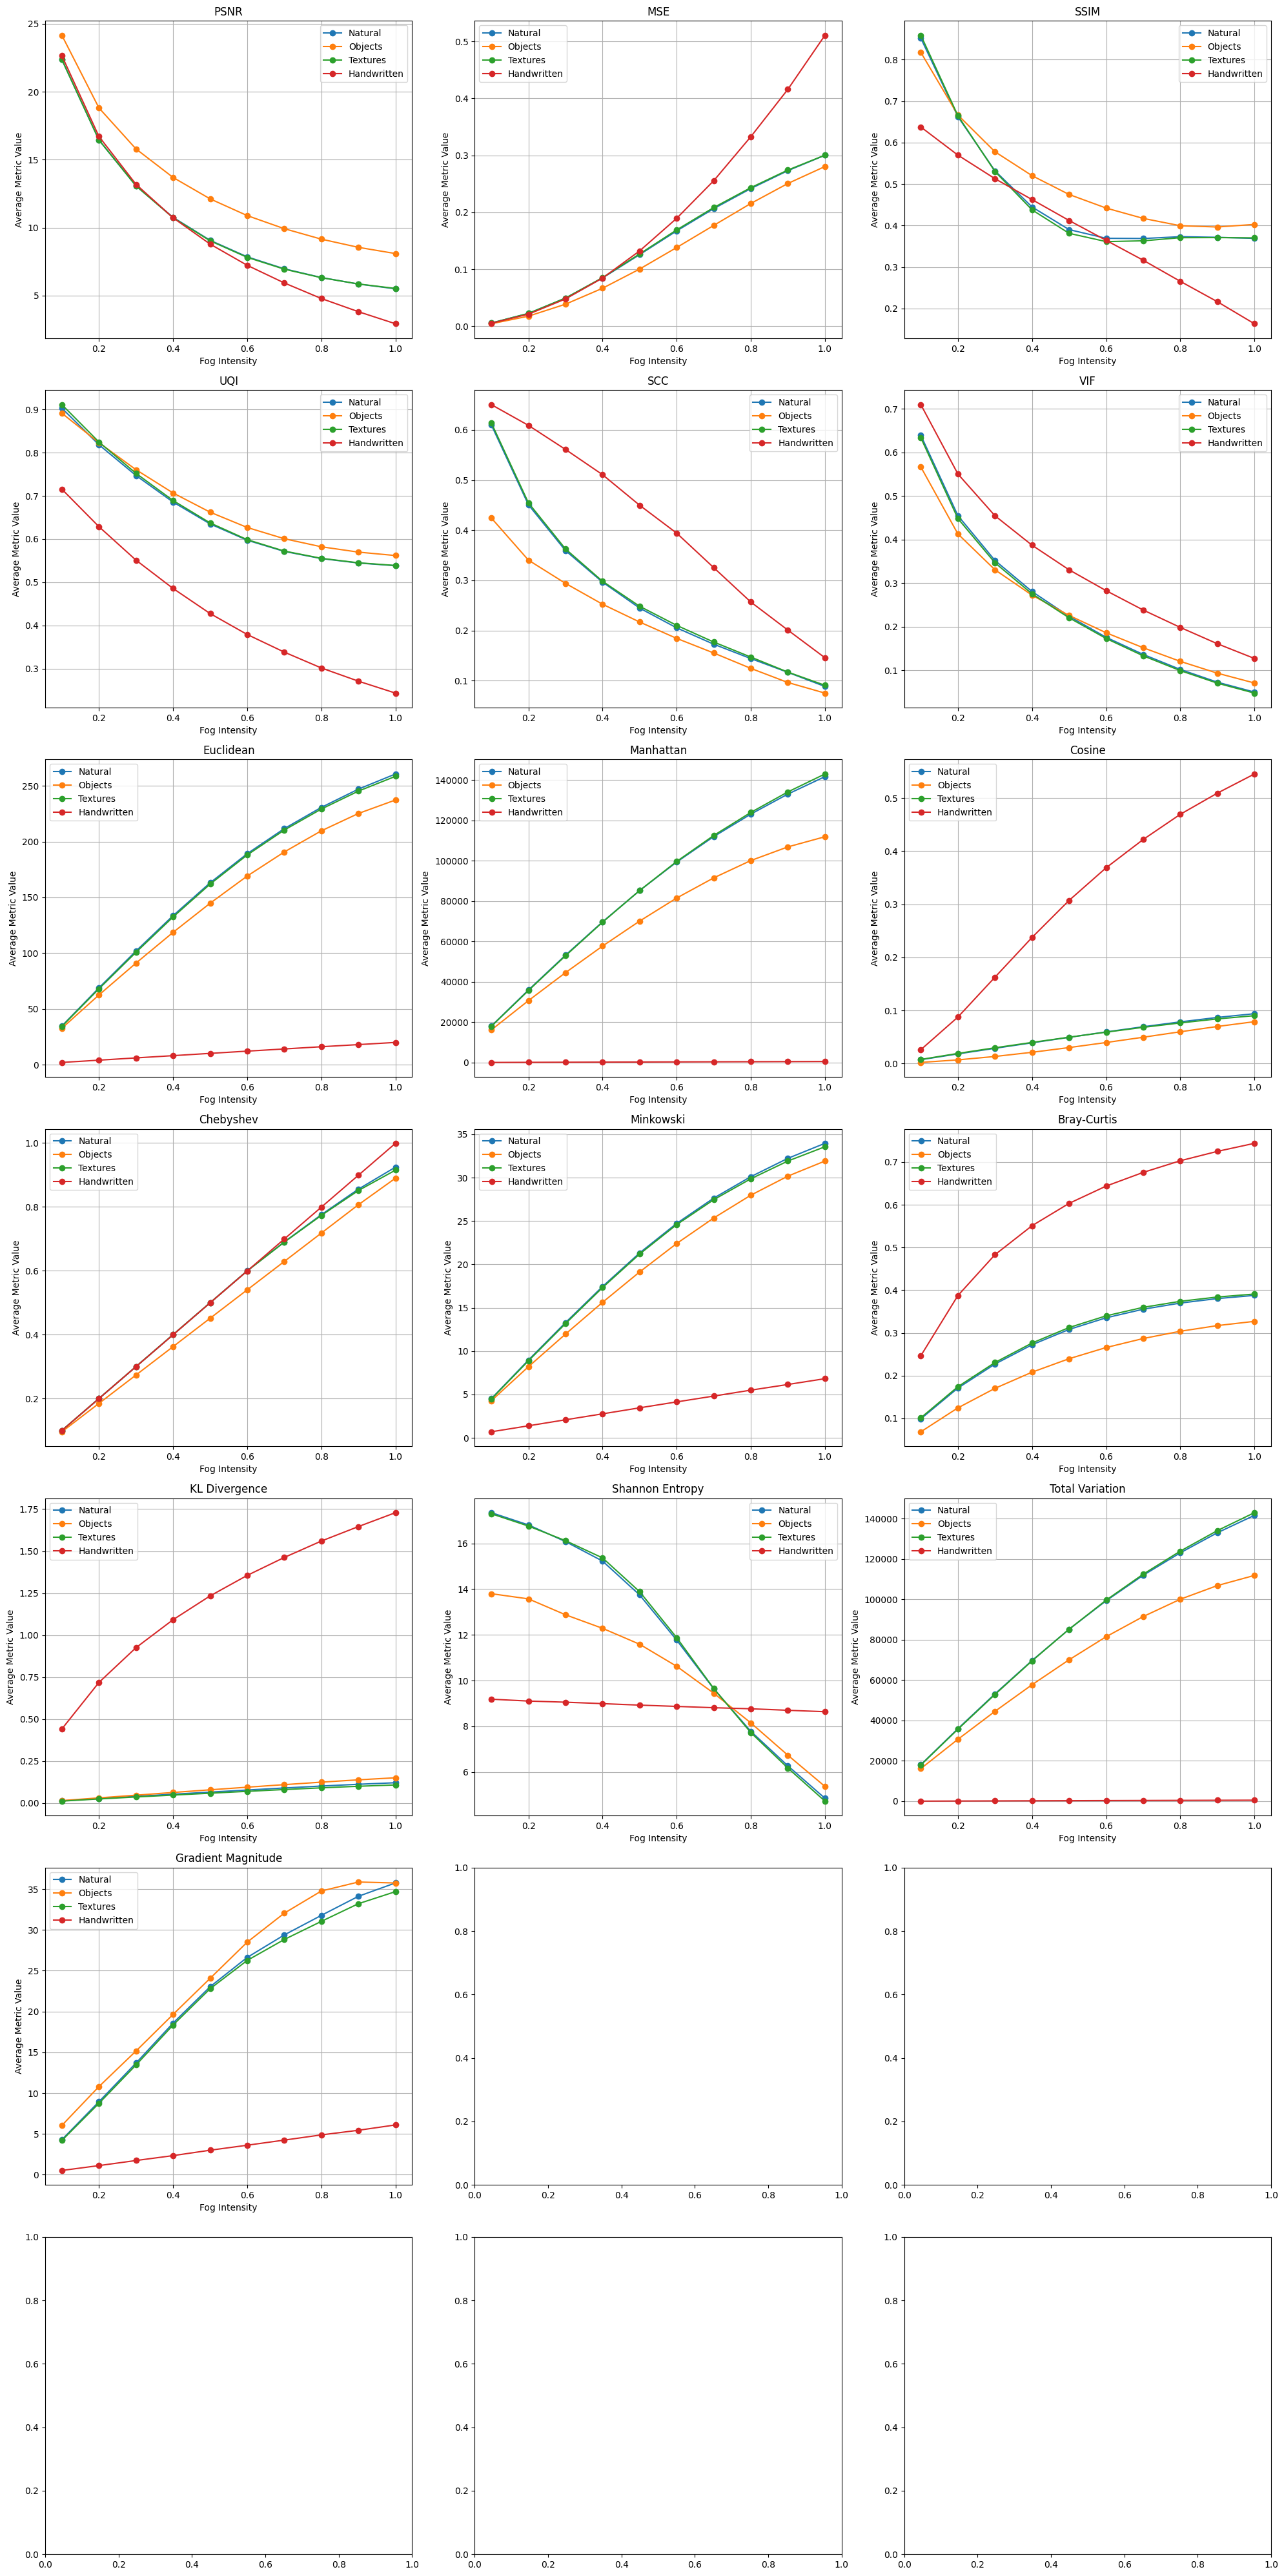

In [ ]:
!pip install sewar
import numpy as np
import matplotlib.pyplot as plt
import sewar
from skimage import data, img_as_float, img_as_ubyte
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
from scipy.spatial.distance import euclidean, cityblock, cosine, chebyshev, minkowski, braycurtis
from scipy.stats import entropy
from skimage.color import rgb2gray, rgba2rgb
from scipy.linalg import norm
from skimage.filters import sobel
from skimage.measure import shannon_entropy
from tensorflow.keras.datasets import mnist

def preprocess_image(image):
    image = img_as_float(image)
    if image.ndim == 3:
        if image.shape[2] == 4:
            image = rgba2rgb(image)
        image = rgb2gray(image)
    return image

def apply_fog_effect(image, intensity=0.5):
    """
    Apply fog effect to the image by adding a haze layer.
    """
    rows, cols = image.shape
    fog_layer = np.random.uniform(low=intensity * 0.5, high=intensity, size=(rows, cols))
    foggy_image = image + fog_layer
    return np.clip(foggy_image, 0, 1)

def compute_metrics(original, modified):
    metrics = {}
    min_side = min(original.shape)
    win_size = min(7, min_side)
    if win_size % 2 == 0:
        win_size -= 1

    original_uint8 = img_as_ubyte(original)
    modified_uint8 = img_as_ubyte(modified)

    metrics['PSNR'] = float(psnr(original, modified, data_range=1))
    metrics['MSE'] = float(np.mean((original - modified) ** 2))
    metrics['SSIM'] = float(ssim(original, modified, data_range=1, win_size=win_size))
    metrics['UQI'] = float(sewar.uqi(original_uint8, modified_uint8))
    metrics['SCC'] = float(sewar.scc(original_uint8, modified_uint8))
    metrics['VIF'] = float(sewar.vifp(original_uint8, modified_uint8))
    metrics['Euclidean'] = float(euclidean(original.ravel(), modified.ravel()))
    metrics['Manhattan'] = float(cityblock(original.ravel(), modified.ravel()))
    metrics['Cosine'] = float(cosine(original.ravel(), modified.ravel()))
    metrics['Chebyshev'] = float(chebyshev(original.ravel(), modified.ravel()))
    metrics['Minkowski'] = float(minkowski(original.ravel(), modified.ravel(), p=3))
    metrics['Bray-Curtis'] = float(braycurtis(original.ravel(), modified.ravel()))
    metrics['KL Divergence'] = float(entropy(original.ravel() + 1e-10, modified.ravel() + 1e-10))
    metrics['Shannon Entropy'] = float(shannon_entropy(modified))
    metrics['Total Variation'] = float(np.sum(np.abs(original - modified)))
    metrics['Gradient Magnitude'] = float(norm(sobel(original) - sobel(modified)))
    return metrics

# Load and preprocess images
categories = {
    "Natural": [preprocess_image(data.astronaut()), preprocess_image(data.camera()),
                 preprocess_image(data.coffee()), preprocess_image(data.chelsea()),
                 preprocess_image(data.clock()), preprocess_image(data.page()),
                 preprocess_image(data.coins()), preprocess_image(data.brick()),
                 preprocess_image(data.text()), preprocess_image(data.hubble_deep_field())],
    "Objects": [preprocess_image(data.checkerboard()), preprocess_image(data.grass()),
                 preprocess_image(data.moon()), preprocess_image(data.rocket()),
                 preprocess_image(data.horse()), preprocess_image(data.camera()),
                 preprocess_image(data.lily()), preprocess_image(data.cell()),
                 preprocess_image(data.camera())],
    "Textures": [preprocess_image(data.brick()), preprocess_image(data.text()),
                  preprocess_image(data.camera()), preprocess_image(data.page()),
                  preprocess_image(data.coins()), preprocess_image(data.chelsea()),
                  preprocess_image(data.clock()), preprocess_image(data.coffee()),
                  preprocess_image(data.hubble_deep_field())],
    "Handwritten": [preprocess_image(mnist.load_data()[0][0][i] / 255.0) for i in range(10)]
}

# Define fog intensity levels and initialize results
fog_intensities = np.linspace(0.1, 1.0, 10)  # Different fog intensity levels
metric_names = list(compute_metrics(np.zeros((10, 10), dtype=np.float32), np.zeros((10, 10), dtype=np.float32)).keys())

results = {category: {key: np.zeros(len(fog_intensities)) for key in metric_names} for category in categories}

# Compute metrics for different fog intensity levels
for category, images in categories.items():
    for image in images:
        for i, intensity in enumerate(fog_intensities):
            foggy_image = apply_fog_effect(image, intensity)
            metrics = compute_metrics(image, foggy_image)
            for key in results[category]:
                results[category][key][i] += metrics[key]

# Normalize results
for category in results:
    for key in results[category]:
        results[category][key] /= len(categories[category])

# Plot the results
fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))
axes = axes.ravel()

for i, key in enumerate(results['Natural']):
    for category in results:
        axes[i].plot(fog_intensities, results[category][key], marker='o', label=category)
    axes[i].set_title(key)
    axes[i].set_xlabel("Fog Intensity")
    axes[i].set_ylabel("Average Metric Value")
    axes[i].legend()
    axes[i].grid()

# Clean up empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("/content/drive/My Drive/Colab Notebooks/Image_Results/image_fog_quality_metrics.png")
plt.show()


# New Section